# 06 - Modeling - Broad Pool

In [1]:
ENV = 'colab'

from pathlib import Path

if ENV == 'colab':
    DATA_DIR = Path('/content/drive/MyDrive/thesis')
else:
    DATA_DIR = Path('00_data')

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')


Mounted at /content/drive


In [26]:
import re

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, average_precision_score,
    classification_report, roc_auc_score,  ConfusionMatrixDisplay,
)
from sklearn.metrics import roc_auc_score as _auc
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score,
    cross_validate, train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.base import clone

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

from tqdm.auto import tqdm as _tqdm
import optuna

import optuna
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Data

In [3]:
df = pd.read_parquet(str(DATA_DIR / '05_broad_nb.parquet'))

In [4]:
def stratified_cv_splits(y, n_splits=5, test_size=0.2, random_state=42):

    idx = np.arange(len(y))
    trainval_idx, test_idx = train_test_split(
        idx, test_size=test_size, stratify=y, random_state=random_state
    )
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    folds = [(trainval_idx[tr], trainval_idx[val])
             for tr, val in kfold.split(trainval_idx, y[trainval_idx])]
    return folds, test_idx


In [5]:
y_full = df['label'].values
folds, test_idx = stratified_cv_splits(y_full)

trainval_idx = np.setdiff1d(np.arange(len(df)), test_idx)
df_tv = df.iloc[trainval_idx].copy()
df_te = df.iloc[test_idx].copy()

print(f'train + val: {len(df_tv):,}, hold out: {len(df_te):,}')
print(f'positive rate - train + val: {y_full[trainval_idx].mean():.3f}, test: {y_full[test_idx].mean():.3f}')
print(f'fold sizes (train, val): {[(len(tr), len(va)) for tr, va in folds]}')


train + val: 2,100, hold out: 526
positive rate - train + val: 0.500, test: 0.500
fold sizes (train, val): [(1680, 420), (1680, 420), (1680, 420), (1680, 420), (1680, 420)]


# SRQ1: Baselines

making logistic regression variants with grid search to maximize auc pr

In [6]:
def make_lr_variants(max_iter):
    Cs = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]

    def make_gscv(solver, l1_ratio=0.0):
        kwargs = {'l1_ratio': l1_ratio} if l1_ratio else {}
        return GridSearchCV(
            LogisticRegression(solver=solver, max_iter=max_iter, class_weight='balanced', **kwargs),
            param_grid={'C': Cs}, scoring='average_precision', cv=5, n_jobs=-1, refit=True,
        )

    return {
        'LR-L2':    lambda: LogisticRegression(solver='lbfgs', max_iter=max_iter, class_weight='balanced'),
        'LR-L1':    lambda: LogisticRegression(l1_ratio=1.0, solver='liblinear', max_iter=max_iter, class_weight='balanced'),
        'LR-CV-L2': lambda: make_gscv('lbfgs'),
        'LR-CV-L1': lambda: make_gscv('liblinear', l1_ratio=1.0),
    }

def get_best_c(clf):
    if hasattr(clf, 'best_params_'):
        return clf.best_params_['C']
    return None

## 1. Majority class

In [7]:
X_b1 = np.zeros((len(df), 1))

dummy = DummyClassifier(strategy='most_frequent')
cv_b1 = cross_validate(dummy, X_b1, y_full, cv=folds, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)

print(f'cv roc auc: {cv_b1['test_roc_auc'].mean():.4f} ± {cv_b1['test_roc_auc'].std():.4f}')
print(f'cv auc pr: {cv_b1['test_average_precision'].mean():.4f} ± {cv_b1['test_average_precision'].std():.4f}')
print(f'cv accuracy: {cv_b1['test_accuracy'].mean():.4f} ± {cv_b1['test_accuracy'].std():.4f}')

cv roc auc: 0.5000 ± 0.0000
cv auc pr: 0.5000 ± 0.0000
cv accuracy: 0.5000 ± 0.0000


In [ ]:
dummy.fit(X_b1[trainval_idx], y_full[trainval_idx])
y_prob = dummy.predict_proba(X_b1[test_idx])[:, 1]
test_auc = roc_auc_score(y_full[test_idx], y_prob)
test_aucpr = average_precision_score(y_full[test_idx], y_prob)
print(f'test roc auc: {test_auc:.4f}')
print(f'test auc pr: {test_aucpr:.4f}')
print(f'test Accuracy: {accuracy_score(y_full[test_idx], dummy.predict(X_b1[test_idx])):.4f}')

test roc auc: 0.5000
test auc pr: 0.5000
test Accuracy: 0.5000


## 2. Keyword count

In [ ]:
X_b2 = df[['flagged_ratio']].values

for name, clf_fn in make_lr_variants(1000000).items():
    cv = cross_validate(clf_fn(), X_b2, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b2[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_b2[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    print(f'flagged word ratio ({name})')
    print(f'cv roc auc: {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}')
    print(f'cv auc pr: {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}')
    print(f'cv accuracy: {cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}')
    print(f'test roc auc: {test_auc:.4f}, test auc pr: {test_aucpr:.4f}')
    best_c = get_best_c(clf)
    if best_c: print(f'best c: {best_c:.4f}')
    print()

flagged word ratio (LR-L2)
cv roc auc: 0.6552 ± 0.0127
cv auc pr: 0.6552 ± 0.0127
cv accuracy: 0.6381 ± 0.0141
test roc auc: 0.6768, test auc pr: 0.6768

flagged word ratio (LR-L1)
cv roc auc: 0.6552 ± 0.0127
cv auc pr: 0.6552 ± 0.0127
cv accuracy: 0.6381 ± 0.0141
test roc auc: 0.6768, test auc pr: 0.6768



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

flagged word ratio (LR-CV-L2)
cv roc auc: 0.6552 ± 0.0127
cv auc pr: 0.6552 ± 0.0127
cv accuracy: 0.5952 ± 0.0785
test roc auc: 0.6768, test auc pr: 0.6768
best c: 0.0010



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


flagged word ratio (LR-CV-L1)
cv roc auc: 0.6552 ± 0.0127
cv auc pr: 0.6552 ± 0.0127
cv accuracy: 0.6543 ± 0.0128
test roc auc: 0.6768, test auc pr: 0.6768
best c: 0.0010



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


## 3. TF-IDF + logistic regression

vectorizer fit per fold

In [7]:
X_b3_full = df['all_text'].values

In [ ]:
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, stop_words='english')
vec.fit(X_b3_full[trainval_idx])
print(f'Total unique ngrams (trainval): {len(vec.vocabulary_):,}')

Total unique ngrams (trainval): 70,254


In [ ]:
candidates = [1_000, 2_500, 5_000, 10_000, 25_000, 50_000]
aucs = []
for n in candidates:
    pipe = Pipeline([('tfidf', TfidfVectorizer(max_features=n, ngram_range=(1, 2), sublinear_tf=True, stop_words='english')),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))])

    score = cross_val_score(pipe, X_b3_full, y_full, cv=folds, scoring='roc_auc').mean()
    aucs.append(score)
    print(f'{n:>6,}  AUC={score:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(candidates, aucs, marker='o')
plt.xscale('log')
plt.xlabel('max_features')
plt.ylabel('roc auc')
plt.title('tf idf vocab size vs auc')
plt.tight_layout()
plt.show()

 1,000  AUC=0.9887


KeyboardInterrupt: 

In [ ]:
for name, clf_fn in make_lr_variants(1000).items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5_000, ngram_range=(1, 2),
                                  sublinear_tf=True, stop_words='english')),
        ('lr', clf_fn())])

    cv = cross_validate(pipe, X_b3_full, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    pipe2 = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5_000, ngram_range=(1, 2),
                                  sublinear_tf=True, stop_words='english')),
        ('lr', clf_fn())])

    pipe2.fit(X_b3_full[trainval_idx], y_full[trainval_idx])
    y_prob = pipe2.predict_proba(X_b3_full[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)

    print(f'tf idf {name}')
    print(f'cv roc auc: {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}')
    print(f'cv auc pr: {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}')
    print(f'cv acccuracy: {cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  test auc pr: {test_aucpr:.4f}')

    best_c = get_best_c(pipe2['lr'])
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()

tf idf LR-L2
cv roc auc: 0.9937 ± 0.0025
cv auc pr: 0.9933 ± 0.0031
cv acccuracy: 0.9633 ± 0.0081
test roc auc: 0.9907 ,  test auc pr: 0.9769



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

tf idf LR-L1
cv roc auc: 0.9937 ± 0.0025
cv auc pr: 0.9933 ± 0.0031
cv acccuracy: 0.9633 ± 0.0081
test roc auc: 0.9907 ,  test auc pr: 0.9768

tf idf LR-CV-L2
cv roc auc: 0.9943 ± 0.0029
cv auc pr: 0.9937 ± 0.0036
cv acccuracy: 0.9614 ± 0.0106
test roc auc: 0.9917 ,  test auc pr: 0.9779
best c: 5.0000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


tf idf LR-CV-L1
cv roc auc: 0.9943 ± 0.0027
cv auc pr: 0.9938 ± 0.0033
cv acccuracy: 0.9624 ± 0.0106
test roc auc: 0.9916 ,  test auc pr: 0.9819
best c: 50.0000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


## 4. Sentence embeddings + logistic regression

In [8]:
embed_cols = ['title_embeddings_nomic', 'desc_embeddings_nomic']

title_embs = np.array(df['title_embeddings_nomic'].tolist(), dtype=np.float32)
desc_embs = np.array(df['desc_embeddings_nomic'].tolist(),  dtype=np.float32)
X_b4_full = np.hstack([title_embs, desc_embs])

assert X_b4_full.shape[0] == len(df), 'row count mismatch'
assert X_b4_full.dtype == np.float32, 'dtype mismatch - expected float32'
print(f'embedding matrix: {X_b4_full.shape}  dtype={X_b4_full.dtype}')
print(f'  title embs: {title_embs.shape},  desc embs: {desc_embs.shape}')


embedding matrix: (2626, 1536)  dtype=float32
  title embs: (2626, 768),  desc embs: (2626, 768)


In [ ]:
for name, clf_fn in make_lr_variants(5000).items():
    cv = cross_validate(clf_fn(), X_b4_full, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b4_full[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_b4_full[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)

    print(f'sentence embeddings ({name})')
    print(f'cv roc auc: {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}')
    print(f'cv auc pr: {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}')
    print(f'cv accuracy: {cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  Test auc pr: {test_aucpr:.4f}')

    best_c = get_best_c(clf)
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()

sentence embeddings (LR-L2)
cv roc auc: 0.9904 ± 0.0031
cv auc pr: 0.9891 ± 0.0042
cv accuracy: 0.9548 ± 0.0099
test roc auc: 0.9890 ,  Test auc pr: 0.9870



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

sentence embeddings (LR-L1)
cv roc auc: 0.9904 ± 0.0030
cv auc pr: 0.9891 ± 0.0041
cv accuracy: 0.9552 ± 0.0098
test roc auc: 0.9891 ,  Test auc pr: 0.9872

sentence embeddings (LR-CV-L2)
cv roc auc: 0.9909 ± 0.0035
cv auc pr: 0.9891 ± 0.0051
cv accuracy: 0.9524 ± 0.0099
test roc auc: 0.9905 ,  Test auc pr: 0.9886
best c: 5.0000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

sentence embeddings (LR-CV-L1)
cv roc auc: 0.9909 ± 0.0032
cv auc pr: 0.9891 ± 0.0048
cv accuracy: 0.9548 ± 0.0092
test roc auc: 0.9899 ,  Test auc pr: 0.9880
best c: 5.0000



# SRQ2: Metadata

Feature groups

In [9]:
flagged_cols = [
    'total_flagged_terms_total',
    'unique_flagged_words_total',
    'total_pen_terms_abstract',
    'total_nyt_terms_abstract',
    'has_flagged_word_total',
    'avg_repetition',
    'flagged_ratio',
]

text_prop_cols = ['desc_length',
                  'title_length',
                  'desc_word_count']


# dropped: has_spatial, n_themes
engagement_cols = ['popularity',
                   'n_keywords']

# dropped: has_issued
temporal_cols = []

# dropped: has_bureau_code, has_program_code, has_temporal_info
completeness_cols = [
    'has_license',
    'has_periodicity',
    'has_landing_page',
    'org_type_federal',
]

org_cat_cols = ['org_type']
access_cat_cols = ['dcat_access_level']

all_meta_num = flagged_cols + text_prop_cols + engagement_cols + temporal_cols + completeness_cols
all_meta_cat = org_cat_cols + access_cat_cols
input_cols = ['all_text'] + all_meta_num + all_meta_cat

ablation_conditions = {
    'text only': ([], []),
    'text + flagged risk': (flagged_cols,[]),
    'text + text properties': (text_prop_cols, []),
    'text + engagement': (engagement_cols, []),
    'text + completeness': (completeness_cols,[]),
    'text + access level': ([], access_cat_cols),
    'text + org type': ([], org_cat_cols),
    'text + all metadata': (all_meta_num, all_meta_cat),
}

meta_ablation_conditions = {
    'flagged terms': (flagged_cols, []),
    'text properties': (text_prop_cols, []),
    'engagement': (engagement_cols, []),
    'completeness': (completeness_cols,[]),
    'org type': ([], org_cat_cols),
    'access level': ([], access_cat_cols),
    'all numerical': (all_meta_num, []),
    'all categorical': ([], all_meta_cat),
    'all metadata': (all_meta_num,  all_meta_cat),
}

### 5. Metadata only

In [10]:
num_cols_b5 = all_meta_num
cat_cols_b5 = all_meta_cat

X_b5 = df[num_cols_b5 + cat_cols_b5]

pre_b5 = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols_b5),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_b5),
], remainder='drop')

In [ ]:
for name, clf_fn in make_lr_variants(10_000).items():
    pipe = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    cv = cross_validate(pipe, X_b5, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    pipe2 = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    pipe2.fit(X_b5.iloc[trainval_idx], y_full[trainval_idx])
    y_prob = pipe2.predict_proba(X_b5.iloc[test_idx])[:, 1]
    test_auc  = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)

    print(f'metadata ({name})')
    print(f'cv roc auc: {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}')
    print(f'cv auc pr: {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}')
    print(f'cv accuracy: {cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  Test auc pr: {test_aucpr:.4f}')

    best_c = get_best_c(pipe2['clf'])
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()


metadata (LR-L2)
cv roc auc: 0.9684 ± 0.0055
cv auc pr: 0.9713 ± 0.0056
cv accuracy: 0.8900 ± 0.0180
test roc auc: 0.9626 ,  Test auc pr: 0.9668



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

metadata (LR-L1)
cv roc auc: 0.9684 ± 0.0055
cv auc pr: 0.9713 ± 0.0056
cv accuracy: 0.8900 ± 0.0180
test roc auc: 0.9626 ,  Test auc pr: 0.9668

metadata (LR-CV-L2)
cv roc auc: 0.9685 ± 0.0055
cv auc pr: 0.9725 ± 0.0045
cv accuracy: 0.8886 ± 0.0160
test roc auc: 0.9603 ,  Test auc pr: 0.9639
best c: 0.1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


metadata (LR-CV-L1)
cv roc auc: 0.9686 ± 0.0055
cv auc pr: 0.9725 ± 0.0045
cv accuracy: 0.8886 ± 0.0160
test roc auc: 0.9603 ,  Test auc pr: 0.9639
best c: 0.1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


feature importance from best regularised set

In [ ]:
lrcv_pipe = Pipeline([('pre', pre_b5), ('clf', make_lr_variants(10_000)['LR-CV-L2']())])
lrcv_pipe.fit(X_b5.iloc[trainval_idx], y_full[trainval_idx])
feature_names = (num_cols_b5 + lrcv_pipe['pre'].named_transformers_['cat'].get_feature_names_out(cat_cols_b5).tolist())

pd.DataFrame({'feature':  feature_names,'coefficient': lrcv_pipe['clf'].best_estimator_.coef_[0]}).sort_values('coefficient', ascending=False)

,feature,coefficient
21,dcat_access_level_public,1.815084
4,has_flagged_word_total,1.207986
12,has_license,0.749295
10,popularity,0.681809
1,unique_flagged_words_total,0.609896
5,avg_repetition,0.585549
7,desc_length,0.353875
2,total_pen_terms_abstract,0.303234
0,total_flagged_terms_total,0.285076
3,total_nyt_terms_abstract,0.151251


### Feature ablation

In [11]:
def make_ablation_pipeline(num_cols, cat_cols, include_text=True):
    transformers = []
    if include_text:
        transformers.append(
            ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                                      sublinear_tf=True, stop_words='english'), 'all_text')
        )
    if num_cols:
        transformers.append(
            ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols)
        )
    if cat_cols:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        )
    pre = ColumnTransformer(transformers, remainder='drop', sparse_threshold=0)
    return Pipeline([
        ('pre', pre),
        ('lr',  LogisticRegression(solver='lbfgs',
                                   max_iter=5000, class_weight='balanced')),
    ])

#### Metadata only

In [ ]:
X_meta_abl = df[all_meta_num + all_meta_cat]

meta_abl_results = []
for cond_name, (num_cols, cat_cols) in meta_ablation_conditions.items():
    if not num_cols and not cat_cols:
        print(f'skip {cond_name}')
        continue
    pipe = make_ablation_pipeline(num_cols, cat_cols, include_text=False)
    cv = cross_validate(pipe, X_meta_abl, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    pipe.fit(X_meta_abl.iloc[trainval_idx], y_full[trainval_idx])
    y_prob = pipe.predict_proba(X_meta_abl.iloc[test_idx])[:, 1]
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    meta_abl_results.append({
        'condition': cond_name,
        'cv_aucpr': f'{cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}',
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f'{cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}',
        'test_auc': round(test_auc, 4),
    })

    print(f'{cond_name:<20} cv_pr={cv['test_average_precision'].mean():.4f}  '
          f'test_pr={test_aucpr:.4f}  cv_auc={cv['test_roc_auc'].mean():.4f}  '
          f'test_auc={test_auc:.4f}')

flagged terms        cv_pr=0.6948  test_pr=0.7129  cv_auc=0.6948  test_auc=0.7121
text properties      cv_pr=0.7455  test_pr=0.7160  cv_auc=0.7334  test_auc=0.7147
engagement           cv_pr=0.7683  test_pr=0.7642  cv_auc=0.7827  test_auc=0.7828
completeness         cv_pr=0.7004  test_pr=0.7052  cv_auc=0.7214  test_auc=0.7316
org type             cv_pr=0.5043  test_pr=0.5095  cv_auc=0.5043  test_auc=0.5095
access level         cv_pr=0.7065  test_pr=0.6887  cv_auc=0.7903  test_auc=0.7731
all numerical        cv_pr=0.9611  test_pr=0.9544  cv_auc=0.9488  test_auc=0.9459
all categorical      cv_pr=0.7090  test_pr=0.6946  cv_auc=0.7920  test_auc=0.7773
all metadata         cv_pr=0.9713  test_pr=0.9668  cv_auc=0.9684  test_auc=0.9626


In [ ]:
df_meta_abl = pd.DataFrame(meta_abl_results).sort_values('test_aucpr', ascending=False)
df_meta_abl

,condition,cv_aucpr,test_aucpr,cv_auc,test_auc
8,all metadata,0.9713 ± 0.0056,0.9668,0.9684 ± 0.0055,0.9626
6,all numerical,0.9611 ± 0.0064,0.9544,0.9488 ± 0.0081,0.9459
2,engagement,0.7683 ± 0.0175,0.7642,0.7827 ± 0.0106,0.7828
1,text properties,0.7455 ± 0.0143,0.7160,0.7334 ± 0.0193,0.7147
0,flagged terms,0.6948 ± 0.0122,0.7129,0.6948 ± 0.0122,0.7121
3,completeness,0.7004 ± 0.0340,0.7052,0.7214 ± 0.0356,0.7316
7,all categorical,0.7090 ± 0.0134,0.6946,0.7920 ± 0.0136,0.7773
5,access level,0.7065 ± 0.0136,0.6887,0.7903 ± 0.0138,0.7731
4,org type,0.5043 ± 0.0041,0.5095,0.5043 ± 0.0041,0.5095


In [ ]:
df.groupby('label')['has_flagged_terms_total'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1313.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,1313.0,0.319117,0.466312,0.0,0.0,0.0,1.0,1.0


#### Metadata + tf-idf

In [12]:
ablation_runs = list(ablation_conditions.items()) + [
    ('Metadata only', (all_meta_num, all_meta_cat, False)),
]

In [ ]:
X_abl = df[input_cols]

abl_results = []
for item in ablation_runs:
    cond_name, args = item
    if len(args) == 3:
        num_cols, cat_cols, include_text = args
    else:
        num_cols, cat_cols = args
        include_text = True

    pipe = make_ablation_pipeline(num_cols, cat_cols, include_text=include_text)
    cv = cross_validate(pipe, X_abl, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    pipe.fit(X_abl.iloc[trainval_idx], y_full[trainval_idx])
    y_prob  = pipe.predict_proba(X_abl.iloc[test_idx])[:, 1]
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    test_auc = roc_auc_score(y_full[test_idx], y_prob)

    abl_results.append({
        'condition': cond_name,
        'cv_aucpr': f'{cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}',
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f'{cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}',
        'test_auc': round(test_auc, 4),
    })
    print(f'{cond_name:<30}  CV auc pr: {cv['test_average_precision'].mean():.4f}  Test auc pr: {test_aucpr:.4f}  Test  roc auc: {test_auc:.4f}')

df_ablation = pd.DataFrame(abl_results).set_index('condition')
df_ablation


text only                       CV auc pr: 0.9934  Test auc pr: 0.9746  Test  roc auc: 0.9904
text + flagged risk             CV auc pr: 0.9964  Test auc pr: 0.9938  Test  roc auc: 0.9949
text + text properties          CV auc pr: 0.9917  Test auc pr: 0.9769  Test  roc auc: 0.9897
text + engagement               CV auc pr: 0.9900  Test auc pr: 0.9793  Test  roc auc: 0.9887
text + completeness             CV auc pr: 0.9909  Test auc pr: 0.9801  Test  roc auc: 0.9904
text + access level             CV auc pr: 0.9902  Test auc pr: 0.9739  Test  roc auc: 0.9894
text + org type                 CV auc pr: 0.9940  Test auc pr: 0.9756  Test  roc auc: 0.9915
text + all metadata             CV auc pr: 0.9915  Test auc pr: 0.9895  Test  roc auc: 0.9893
Metadata only                   CV auc pr: 0.9713  Test auc pr: 0.9668  Test  roc auc: 0.9626


,cv_aucpr,test_aucpr,cv_auc,test_auc
condition,,,,
text only,0.9934 ± 0.0035,0.9746,0.9940 ± 0.0027,0.9904
text + flagged risk,0.9964 ± 0.0020,0.9938,0.9963 ± 0.0019,0.9949
text + text properties,0.9917 ± 0.0040,0.9769,0.9920 ± 0.0030,0.9897
text + engagement,0.9900 ± 0.0058,0.9793,0.9905 ± 0.0046,0.9887
text + completeness,0.9909 ± 0.0034,0.9801,0.9912 ± 0.0027,0.9904
text + access level,0.9902 ± 0.0043,0.9739,0.9900 ± 0.0042,0.9894
text + org type,0.9940 ± 0.0035,0.9756,0.9946 ± 0.0026,0.9915
text + all metadata,0.9915 ± 0.0035,0.9895,0.9908 ± 0.0034,0.9893
Metadata only,0.9713 ± 0.0056,0.9668,0.9684 ± 0.0055,0.9626


#### Metadata + embeddings

In [13]:
num_cols_b6 = all_meta_num
cat_cols_b6 = all_meta_cat

meta_pre_b6 = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols_b6),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_b6),
], remainder='drop')

In [14]:
# Fit only on trainval to keep test set clean
meta_pre_b6.fit(df.iloc[trainval_idx][num_cols_b6 + cat_cols_b6])
meta_all = meta_pre_b6.transform(df[num_cols_b6 + cat_cols_b6])
print(f'Meta matrix: {meta_all.shape}')

# Reuse title+desc embeddings from baseline 4
X_b6_full = np.hstack([X_b4_full, meta_all]).astype(np.float32)
print(f'Embeddings + metadata matrix: {X_b6_full.shape}')

Meta matrix: (2626, 23)
Embeddings + metadata matrix: (2626, 1559)


In [ ]:
for name, clf_fn in make_lr_variants(10_000).items():
    cv = cross_validate(clf_fn(), X_b6_full, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b6_full[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_b6_full[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)

    print(f'Embeddings + metadata ({name})')
    print(f'cv roc auc: {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}')
    print(f'cv auc pr: {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}')
    print(f'cv accuracy: {cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  Test auc pr: {test_aucpr:.4f}')

    best_c = get_best_c(clf)
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()



Embeddings + metadata (LR-L2)
cv roc auc: 0.9944 ± 0.0022
cv auc pr: 0.9944 ± 0.0024
cv accuracy: 0.9643 ± 0.0112
test roc auc: 0.9944 ,  Test auc pr: 0.9943



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

Embeddings + metadata (LR-L1)
cv roc auc: 0.9944 ± 0.0022
cv auc pr: 0.9944 ± 0.0024
cv accuracy: 0.9648 ± 0.0106
test roc auc: 0.9944 ,  Test auc pr: 0.9943

Embeddings + metadata (LR-CV-L2)
cv roc auc: 0.9952 ± 0.0025
cv auc pr: 0.9950 ± 0.0030
cv accuracy: 0.9729 ± 0.0101
test roc auc: 0.9959 ,  Test auc pr: 0.9955
best c: 5.0000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

Embeddings + metadata (LR-CV-L1)
cv roc auc: 0.9951 ± 0.0025
cv auc pr: 0.9949 ± 0.0029
cv accuracy: 0.9710 ± 0.0105
test roc auc: 0.9959 ,  Test auc pr: 0.9955
best c: 5.0000



In [ ]:
abl_emb_results = []

for item in ablation_runs:
    cond_name, args = item
    if len(args) == 3:
        num_cols, cat_cols, _ = args
    else:
        num_cols, cat_cols = args

    if num_cols or cat_cols:
        meta_transformers = []
        if num_cols:
            meta_transformers.append(
                ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols)
            )
        if cat_cols:
            meta_transformers.append(
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
            )
        meta_pre = ColumnTransformer(meta_transformers, remainder='drop', sparse_threshold=0)
        meta_cols = num_cols + cat_cols
        meta_pre.fit(df.iloc[trainval_idx][meta_cols])
        meta_all_cond = meta_pre.transform(df[meta_cols])

        if cond_name == 'Metadata only':
            X_cond = meta_all_cond
        else:
            X_cond = np.hstack([X_b4_full, meta_all_cond])
    else:
        X_cond = X_b4_full

    clf = LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced')
    cv = cross_validate(clone(clf), X_cond, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    clf.fit(X_cond[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_cond[test_idx])[:, 1]
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    test_auc = roc_auc_score(y_full[test_idx], y_prob)

    abl_emb_results.append({
        'condition':  cond_name,
        'cv_aucpr': f'{cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}',
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f'{cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}',
        'test_auc': round(test_auc, 4),
    })
    print(f'{cond_name:<30}  CV auc pr: {cv['test_average_precision'].mean():.4f}  Test auc pr: {test_aucpr:.4f}  Test  roc auc: {test_auc:.4f}')

df_ablation_emb = pd.DataFrame(abl_emb_results).set_index('condition')
df_ablation_emb

text only                       CV auc pr: 0.9891  Test auc pr: 0.9870  Test  roc auc: 0.9890
text + flagged risk             CV auc pr: 0.9942  Test auc pr: 0.9933  Test  roc auc: 0.9937
text + text properties          CV auc pr: 0.9901  Test auc pr: 0.9869  Test  roc auc: 0.9898
text + engagement               CV auc pr: 0.9894  Test auc pr: 0.9865  Test  roc auc: 0.9885
text + completeness             CV auc pr: 0.9893  Test auc pr: 0.9883  Test  roc auc: 0.9901
text + access level             CV auc pr: 0.9896  Test auc pr: 0.9879  Test  roc auc: 0.9897
text + org type                 CV auc pr: 0.9892  Test auc pr: 0.9881  Test  roc auc: 0.9901
text + all metadata             CV auc pr: 0.9944  Test auc pr: 0.9943  Test  roc auc: 0.9944
Metadata only                   CV auc pr: 0.9713  Test auc pr: 0.9668  Test  roc auc: 0.9626


,cv_aucpr,test_aucpr,cv_auc,test_auc
condition,,,,
text only,0.9891 ± 0.0042,0.9870,0.9904 ± 0.0031,0.9890
text + flagged risk,0.9942 ± 0.0024,0.9933,0.9943 ± 0.0022,0.9937
text + text properties,0.9901 ± 0.0038,0.9869,0.9909 ± 0.0029,0.9898
text + engagement,0.9894 ± 0.0046,0.9865,0.9902 ± 0.0040,0.9885
text + completeness,0.9893 ± 0.0045,0.9883,0.9905 ± 0.0035,0.9901
text + access level,0.9896 ± 0.0036,0.9879,0.9903 ± 0.0030,0.9897
text + org type,0.9892 ± 0.0042,0.9881,0.9905 ± 0.0031,0.9901
text + all metadata,0.9944 ± 0.0024,0.9943,0.9944 ± 0.0022,0.9944
Metadata only,0.9713 ± 0.0056,0.9668,0.9684 ± 0.0056,0.9626


#### Confusion matrix

with the last pipe from tf idf ablation (metadata only, refit on trainval with text + metadata)

              precision    recall  f1-score   support

 not at risk       0.94      0.95      0.95       263
     at risk       0.95      0.94      0.95       263

    accuracy                           0.95       526
   macro avg       0.95      0.95      0.95       526
weighted avg       0.95      0.95      0.95       526



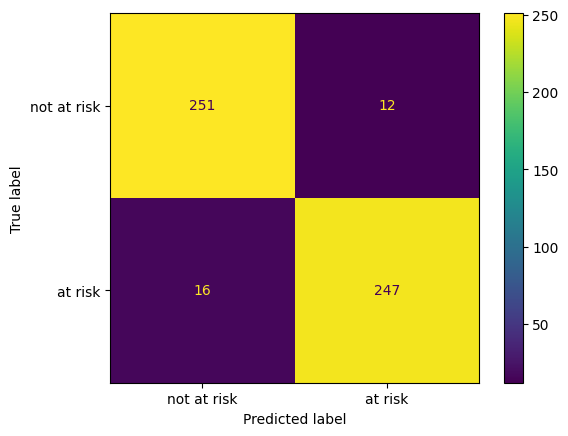

In [ ]:
best_abl_pipe = make_ablation_pipeline(all_meta_num, all_meta_cat, include_text=True)
best_abl_pipe.fit(X_abl.iloc[trainval_idx], y_full[trainval_idx])
y_pred = best_abl_pipe.predict(X_abl.iloc[test_idx])

print(classification_report(y_full[test_idx], y_pred, target_names=['not at risk', 'at risk']))

ConfusionMatrixDisplay.from_predictions(y_full[test_idx], y_pred, display_labels=['not at risk', 'at risk'])
plt.show()


## SRQ3: Model comparison

all three conditions
* text only
* metadata only
* text + metadata

## SRQ3 (Optuna) - Broad pool

In [15]:
!pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 32.3 MB/s eta 0:00:00


In [24]:
def run_optuna_model(model_name, make_objective_fn, make_model_fn,
                     conditions, y_tr, y_te, skf, n_trials=30):

    results = {}
    n_conds = len(conditions)
    for ci, (cond_name, (X_tr, X_te)) in enumerate(conditions.items(), 1):
        print(f"\n  [{model_name}] {cond_name}  (condition {ci}/{n_conds}, {n_trials} trials)",
              flush=True)
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=42),
        )

        def _cb(study, trial):
            _tqdm.write(
                f"    t{trial.number + 1:>3}/{n_trials}  "
                f"val={trial.value:.4f}  best={study.best_value:.4f}"
            )

        study.optimize(
            lambda trial: make_objective_fn(trial, X_tr, y_tr),
            n_trials=n_trials,
            show_progress_bar=True,
            callbacks=[_cb],
        )
        print(f"  → best: {study.best_params}", flush=True)
        print(f"  → final CV ({skf.get_n_splits()} folds)...", flush=True)
        model = make_model_fn(study.best_params)
        cv = cross_validate(model, X_tr, y_tr, cv=skf,
                            scoring=['average_precision', 'roc_auc'],
                            return_train_score=True)
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_te)[:, 1]
        test_aucpr = average_precision_score(y_te, y_prob)
        test_auc = roc_auc_score(y_te, y_prob)
        results[cond_name] = dict(
            best_params = study.best_params,
            cv_aucpr_mean = cv["test_average_precision"].mean(),
            cv_aucpr_std = cv["test_average_precision"].std(),
            cv_auc_mean = cv["test_roc_auc"].mean(),
            test_aucpr = test_aucpr,
            test_auc = test_auc,
            model = model,
        )
        print(f"CV AUC-PR={study.best_value:.4f}  "
              f"test AUC-PR={test_aucpr:.4f}  test ROC-AUC={test_auc:.4f}")
    return results


def make_xgb_objective(class_ratio, skf):
    def objective(trial, X_tr, y_tr):
        model = XGBClassifier(
            max_depth = trial.suggest_int('max_depth', 3, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            n_estimators = trial.suggest_int('n_estimators', 100, 2000),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
            subsample = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            gamma = trial.suggest_float('gamma', 0.0, 1.0),
            scale_pos_weight = class_ratio,
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', device='cuda', random_state=42, verbosity=0)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='average_precision', n_jobs=1).mean()
    return objective

def make_xgb_model(class_ratio):
    def factory(params):
        return XGBClassifier(
            **{k: params[k] for k in [
                'max_depth','learning_rate','n_estimators','min_child_weight',
                'subsample','colsample_bytree','reg_alpha','reg_lambda','gamma']},
            scale_pos_weight=class_ratio,
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', device='cuda', random_state=42, n_jobs=1, verbosity=0)
    return factory


def make_lgb_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = lgb.LGBMClassifier(
            num_leaves = trial.suggest_int('num_leaves', 20, 300),
            max_depth = trial.suggest_int('max_depth', 3, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            n_estimators = trial.suggest_int('n_estimators', 100, 1500),
            min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
            subsample = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            class_weight='balanced', random_state=42, device='gpu', verbose=-1)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                       scoring='average_precision', n_jobs=1).mean()

    return objective

def make_lgb_model():
    def factory(params):
        return lgb.LGBMClassifier(
            **{k: params[k] for k in [
                'num_leaves','max_depth','learning_rate','n_estimators',
                'min_child_samples','subsample','colsample_bytree','reg_alpha','reg_lambda']},
            class_weight='balanced', random_state=42, device='gpu', n_jobs=1, verbose=-1)
    return factory


def make_svc_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = CalibratedClassifierCV(
            LinearSVC(C=trial.suggest_float('C', 1e-3, 1e2, log=True),
                      class_weight='balanced', max_iter=5000))
        return cross_val_score(model, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_svc_model():
    def factory(params):
        return CalibratedClassifierCV(
            LinearSVC(C=params['C'], class_weight='balanced', max_iter=5000))
    return factory


def make_rf_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = RandomForestClassifier(
            n_estimators = trial.suggest_int('n_estimators', 100, 500),
            max_depth = trial.suggest_int('max_depth', 3, 15),
            min_samples_leaf= trial.suggest_int('min_samples_leaf', 1, 10),
            max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)

        return cross_val_score(model, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_rf_model():
    def factory(params):
        return RandomForestClassifier(
            **{k: params[k] for k in
               ['n_estimators','max_depth','min_samples_leaf','max_features']},
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    return factory


def make_hgb_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = HistGradientBoostingClassifier(
            max_iter = trial.suggest_int('max_iter', 100, 500),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth = trial.suggest_int('max_depth', 2, 6),
            min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20),
            l2_regularization = trial.suggest_float('l2_regularization', 1e-4, 1.0, log=True),
            class_weight='balanced', random_state=42)

        return cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_hgb_model():
    def factory(params):
        return HistGradientBoostingClassifier(
            **{k: params[k] for k in
               ['max_iter','learning_rate','max_depth','min_samples_leaf','l2_regularization']},
            class_weight='balanced', random_state=42)
    return factory


def make_catboost_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = CatBoostClassifier(
            depth = trial.suggest_int('depth', 4, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            iterations = trial.suggest_int('iterations', 200, 2000),
            l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            bagging_temperature= trial.suggest_float('bagging_temperature', 0.0, 1.0),
            random_strength = trial.suggest_float('random_strength', 0.0, 2.0),
            auto_class_weights='Balanced', eval_metric='AUC', task_type='GPU', random_seed=42, verbose=0)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                       scoring='average_precision', n_jobs=1).mean()
    return objective

def make_catboost_model():
    def factory(params):
        return CatBoostClassifier(
            **{k: params[k] for k in [
                'depth','learning_rate','iterations','l2_leaf_reg',
                'bagging_temperature','random_strength']},
            auto_class_weights='Balanced', eval_metric='AUC', task_type='GPU', random_seed=42, n_jobs=1, verbose=0)
    return factory


ARCH_CHOICES_SKLEARN = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
]

def make_mlp_objective(skf):
    def objective(trial, X_tr, y_tr):
        arch = ARCH_CHOICES_SKLEARN[
            trial.suggest_int('arch_idx', 0, len(ARCH_CHOICES_SKLEARN) - 1)]
        model = MLPClassifier(
            hidden_layer_sizes = arch,
            activation = 'relu',
            alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
            batch_size = trial.suggest_categorical('batch_size', [64, 128, 256]),
            max_iter=300, early_stopping=True, random_state=42,
        )
        return cross_val_score(model, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=1).mean()

    return objective

def make_mlp_model():
    def factory(params):
        arch = ARCH_CHOICES_SKLEARN[params['arch_idx']]
        return MLPClassifier(
            hidden_layer_sizes=arch, activation='relu',
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            batch_size=params['batch_size'],
            max_iter=300, early_stopping=True, random_state=42)
    return factory

print("run_optuna_model and factory functions defined.")

run_optuna_model and factory functions defined.


In [21]:
_tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                               sublinear_tf=True, stop_words='english')
_tfidf.fit(df.iloc[trainval_idx]['all_text'])
tfidf_tv = _tfidf.transform(df.iloc[trainval_idx]['all_text']).toarray()
tfidf_te = _tfidf.transform(df.iloc[test_idx]['all_text']).toarray()

meta_tv = meta_all[trainval_idx]; meta_te = meta_all[test_idx]
emb_tv = X_b4_full[trainval_idx]; emb_te  = X_b4_full[test_idx]
b6_tv = X_b6_full[trainval_idx]; b6_te = X_b6_full[test_idx]
y_tv = y_full[trainval_idx]; y_te = y_full[test_idx]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
class_ratio = float((y_tv == 0).sum()) / float((y_tv == 1).sum())
print(f"Class ratio (neg/pos): {class_ratio:.2f}")

conditions = {
    'Text TF-IDF': (tfidf_tv, tfidf_te),
    'Metadata': (meta_tv, meta_te),
    'Text+Meta TF-IDF': (np.hstack([tfidf_tv, meta_tv]), np.hstack([tfidf_te, meta_te])),
    'Text Emb': (emb_tv, emb_te),
    'Text+Meta Emb': (b6_tv, b6_te),
}
catboost_conds = {k: v for k, v in conditions.items()
                        if k in ('Metadata', 'Text+Meta Emb')}
print(f"Conditions: {list(conditions.keys())}")

Class ratio (neg/pos): 1.00
Conditions: ['Text TF-IDF', 'Metadata', 'Text+Meta TF-IDF', 'Text Emb', 'Text+Meta Emb']


#### XGBoost

In [27]:
xgb = run_optuna_model(
    'XGBoost',
    make_xgb_objective(class_ratio, skf),
    make_xgb_model(class_ratio),
    conditions, y_tv, y_te, skf, n_trials=80)


  [XGBoost] Text TF-IDF  (condition 1/5, 80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9670  best=0.9670
    t  2/80  val=0.9694  best=0.9694
    t  3/80  val=0.9853  best=0.9853
    t  4/80  val=0.9703  best=0.9853
    t  5/80  val=0.9747  best=0.9853
    t  6/80  val=0.9721  best=0.9853
    t  7/80  val=0.9816  best=0.9853
    t  8/80  val=0.9783  best=0.9853
    t  9/80  val=0.9721  best=0.9853
    t 10/80  val=0.9813  best=0.9853
    t 11/80  val=0.9685  best=0.9853
    t 12/80  val=0.9873  best=0.9873
    t 13/80  val=0.9873  best=0.9873
    t 14/80  val=0.9869  best=0.9873
    t 15/80  val=0.9873  best=0.9873
    t 16/80  val=0.9850  best=0.9873
    t 17/80  val=0.9851  best=0.9873
    t 18/80  val=0.9876  best=0.9876
    t 19/80  val=0.9841  best=0.9876
    t 20/80  val=0.9828  best=0.9876
    t 21/80  val=0.9854  best=0.9876
    t 22/80  val=0.9869  best=0.9876
    t 23/80  val=0.9863  best=0.9876
    t 24/80  val=0.9862  best=0.9876
    t 25/80  val=0.9851  best=0.9876
    t 26/80  val=0.9847  best=0.9876
    t 27/80  val=0.9888  best=0.9888
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9810  best=0.9810
    t  2/80  val=0.9844  best=0.9844
    t  3/80  val=0.9869  best=0.9869
    t  4/80  val=0.9818  best=0.9869
    t  5/80  val=0.9862  best=0.9869
    t  6/80  val=0.9850  best=0.9869
    t  7/80  val=0.9831  best=0.9869
    t  8/80  val=0.9846  best=0.9869
    t  9/80  val=0.9842  best=0.9869
    t 10/80  val=0.9874  best=0.9874
    t 11/80  val=0.9830  best=0.9874
    t 12/80  val=0.9876  best=0.9876
    t 13/80  val=0.9860  best=0.9876
    t 14/80  val=0.9842  best=0.9876
    t 15/80  val=0.9880  best=0.9880
    t 16/80  val=0.9886  best=0.9886
    t 17/80  val=0.9886  best=0.9886
    t 18/80  val=0.9878  best=0.9886
    t 19/80  val=0.9884  best=0.9886
    t 20/80  val=0.9875  best=0.9886
    t 21/80  val=0.9865  best=0.9886
    t 22/80  val=0.9887  best=0.9887
    t 23/80  val=0.9880  best=0.9887
    t 24/80  val=0.9885  best=0.9887
    t 25/80  val=0.9875  best=0.9887
    t 26/80  val=0.9884  best=0.9887
    t 27/80  val=0.9827  best=0.9887
 

...

    t  1/80  val=0.9899  best=0.9899
    t  2/80  val=0.9896  best=0.9899
    t  3/80  val=0.9937  best=0.9937
    t  4/80  val=0.9867  best=0.9937
    t  5/80  val=0.9904  best=0.9937
    t  6/80  val=0.9893  best=0.9937
    t  7/80  val=0.9925  best=0.9937
    t  8/80  val=0.9898  best=0.9937
    t  9/80  val=0.9895  best=0.9937
    t 10/80  val=0.9913  best=0.9937
    t 11/80  val=0.9901  best=0.9937
    t 12/80  val=0.9940  best=0.9940
    t 13/80  val=0.9939  best=0.9940
    t 14/80  val=0.9935  best=0.9940
    t 15/80  val=0.9940  best=0.9940
    t 16/80  val=0.9931  best=0.9940
    t 17/80  val=0.9931  best=0.9940
    t 18/80  val=0.9934  best=0.9940
    t 19/80  val=0.9933  best=0.9940
    t 20/80  val=0.9922  best=0.9940
    t 21/80  val=0.9935  best=0.9940
    t 22/80  val=0.9940  best=0.9940
    t 23/80  val=0.9933  best=0.9940
    t 24/80  val=0.9938  best=0.9940
    t 25/80  val=0.9923  best=0.9940
    t 26/80  val=0.9928  best=0.9940
    t 27/80  val=0.9931  best=0.9940
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9902  best=0.9902
    t  2/80  val=0.9909  best=0.9909
    t  3/80  val=0.9916  best=0.9916
    t  4/80  val=0.9888  best=0.9916
    t  5/80  val=0.9913  best=0.9916
    t  6/80  val=0.9911  best=0.9916
    t  7/80  val=0.9893  best=0.9916
    t  8/80  val=0.9904  best=0.9916
    t  9/80  val=0.9900  best=0.9916
    t 10/80  val=0.9910  best=0.9916
    t 11/80  val=0.9902  best=0.9916
    t 12/80  val=0.9911  best=0.9916
    t 13/80  val=0.9919  best=0.9919
    t 14/80  val=0.9917  best=0.9919
    t 15/80  val=0.9921  best=0.9921
    t 16/80  val=0.9921  best=0.9921
    t 17/80  val=0.9913  best=0.9921
    t 18/80  val=0.9912  best=0.9921
    t 19/80  val=0.9906  best=0.9921
    t 20/80  val=0.9917  best=0.9921
    t 21/80  val=0.9911  best=0.9921
    t 22/80  val=0.9917  best=0.9921
    t 23/80  val=0.9917  best=0.9921
    t 24/80  val=0.9920  best=0.9921
    t 25/80  val=0.9919  best=0.9921
    t 26/80  val=0.9904  best=0.9921
    t 27/80  val=0.9912  best=0.9921
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9918  best=0.9918
    t  2/80  val=0.9934  best=0.9934
    t  3/80  val=0.9944  best=0.9944
    t  4/80  val=0.9931  best=0.9944
    t  5/80  val=0.9940  best=0.9944
    t  6/80  val=0.9935  best=0.9944
    t  7/80  val=0.9907  best=0.9944
    t  8/80  val=0.9937  best=0.9944
    t  9/80  val=0.9931  best=0.9944
    t 10/80  val=0.9944  best=0.9944
    t 11/80  val=0.9930  best=0.9944
    t 12/80  val=0.9938  best=0.9944
    t 13/80  val=0.9942  best=0.9944
    t 14/80  val=0.9946  best=0.9946
    t 15/80  val=0.9946  best=0.9946
    t 16/80  val=0.9946  best=0.9946
    t 17/80  val=0.9947  best=0.9947
    t 18/80  val=0.9944  best=0.9947
    t 19/80  val=0.9946  best=0.9947
    t 20/80  val=0.9943  best=0.9947
    t 21/80  val=0.9944  best=0.9947
    t 22/80  val=0.9946  best=0.9947
    t 23/80  val=0.9946  best=0.9947
    t 24/80  val=0.9946  best=0.9947
    t 25/80  val=0.9940  best=0.9947
    t 26/80  val=0.9945  best=0.9947
    t 27/80  val=0.9936  best=0.9947
 

#### LightGBM

In [29]:
lgb = run_optuna_model(
    'LightGBM',
    make_lgb_objective(skf),
    make_lgb_model(),
    conditions, y_tv, y_te, skf, n_trials=20)


  [LightGBM] Text TF-IDF  (condition 1/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    t  1/20  val=0.9879  best=0.9879


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    t 20/20  val=0.9954  best=0.9958
  → best: {'num_leaves': 63, 'max_depth': 7, 'learning_rate': 0.18265264064160544, 'n_estimators': 770, 'min_child_samples': 91, 'subsample': 0.6041750647925002, 'colsample_bytree': 0.8995760102498102, 'reg_alpha': 0.000509129935124461, 'reg_lambda': 0.0054641525885255745}
  → final CV (5 folds)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

CV AUC-PR=0.9958  test AUC-PR=0.9876  test ROC-AUC=0.9908


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### LinearSVC

In [30]:
svc = run_optuna_model(
    'LinearSVC',
    make_svc_objective(skf),
    make_svc_model(),
    conditions, y_tv, y_te, skf, n_trials=20)


  [LinearSVC] Text TF-IDF  (condition 1/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9924  best=0.9924
    t  2/20  val=0.9928  best=0.9928
    t  3/20  val=0.9929  best=0.9929
    t  4/20  val=0.9931  best=0.9931
    t  5/20  val=0.9905  best=0.9931
    t  6/20  val=0.9905  best=0.9931
    t  7/20  val=0.9897  best=0.9931
    t  8/20  val=0.9929  best=0.9931
    t  9/20  val=0.9931  best=0.9931
    t 10/20  val=0.9931  best=0.9931
    t 11/20  val=0.9919  best=0.9931
    t 12/20  val=0.9923  best=0.9931
    t 13/20  val=0.9930  best=0.9931
    t 14/20  val=0.9924  best=0.9931
    t 15/20  val=0.9931  best=0.9931
    t 16/20  val=0.9929  best=0.9931
    t 17/20  val=0.9928  best=0.9931
    t 18/20  val=0.9924  best=0.9931
    t 19/20  val=0.9931  best=0.9931
    t 20/20  val=0.9928  best=0.9931
  → best: {'C': 1.0129197956845732}
  → final CV (5 folds)...
CV AUC-PR=0.9931  test AUC-PR=0.9858  test ROC-AUC=0.9916

  [LinearSVC] Metadata  (condition 2/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9706  best=0.9706
    t  2/20  val=0.9685  best=0.9706
    t  3/20  val=0.9694  best=0.9706
    t  4/20  val=0.9696  best=0.9706
    t  5/20  val=0.9710  best=0.9710
    t  6/20  val=0.9710  best=0.9710
    t  7/20  val=0.9657  best=0.9710
    t  8/20  val=0.9687  best=0.9710
    t  9/20  val=0.9696  best=0.9710
    t 10/20  val=0.9695  best=0.9710
    t 11/20  val=0.9709  best=0.9710
    t 12/20  val=0.9601  best=0.9710
    t 13/20  val=0.9713  best=0.9713
    t 14/20  val=0.9711  best=0.9713
    t 15/20  val=0.9706  best=0.9713
    t 16/20  val=0.9713  best=0.9713
    t 17/20  val=0.9705  best=0.9713
    t 18/20  val=0.9712  best=0.9713
    t 19/20  val=0.9705  best=0.9713
    t 20/20  val=0.9713  best=0.9713
  → best: {'C': 0.01937548950083421}
  → final CV (5 folds)...
CV AUC-PR=0.9713  test AUC-PR=0.9642  test ROC-AUC=0.9591

  [LinearSVC] Text+Meta TF-IDF  (condition 3/5, 20 trials)


...

CV AUC-PR=0.9969  test AUC-PR=0.9951  test ROC-AUC=0.9960

  [LinearSVC] Text Emb  (condition 4/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9873  best=0.9873
    t  2/20  val=0.9858  best=0.9873
    t  3/20  val=0.9866  best=0.9873
    t  4/20  val=0.9879  best=0.9879
    t  5/20  val=0.9775  best=0.9879
    t  6/20  val=0.9775  best=0.9879
    t  7/20  val=0.9725  best=0.9879
    t  8/20  val=0.9860  best=0.9879
    t  9/20  val=0.9880  best=0.9880
    t 10/20  val=0.9867  best=0.9880
    t 11/20  val=0.9884  best=0.9884
    t 12/20  val=0.9883  best=0.9884
    t 13/20  val=0.9874  best=0.9884
    t 14/20  val=0.9877  best=0.9884
    t 15/20  val=0.9884  best=0.9884
    t 16/20  val=0.9884  best=0.9884
    t 17/20  val=0.9829  best=0.9884
    t 18/20  val=0.9877  best=0.9884
    t 19/20  val=0.9837  best=0.9884
    t 20/20  val=0.9884  best=0.9884
  → best: {'C': 0.2392223638943376}
  → final CV (5 folds)...
CV AUC-PR=0.9884  test AUC-PR=0.9888  test ROC-AUC=0.9902

  [LinearSVC] Text+Meta Emb  (condition 5/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9938  best=0.9938
    t  2/20  val=0.9931  best=0.9938
    t  3/20  val=0.9935  best=0.9938
    t  4/20  val=0.9944  best=0.9944
    t  5/20  val=0.9836  best=0.9944
    t  6/20  val=0.9836  best=0.9944
    t  7/20  val=0.9779  best=0.9944
    t  8/20  val=0.9932  best=0.9944
    t  9/20  val=0.9944  best=0.9944
    t 10/20  val=0.9938  best=0.9944
    t 11/20  val=0.9946  best=0.9946
    t 12/20  val=0.9946  best=0.9946
    t 13/20  val=0.9939  best=0.9946
    t 14/20  val=0.9941  best=0.9946
    t 15/20  val=0.9946  best=0.9946
    t 16/20  val=0.9947  best=0.9947
    t 17/20  val=0.9899  best=0.9947
    t 18/20  val=0.9943  best=0.9947
    t 19/20  val=0.9906  best=0.9947
    t 20/20  val=0.9947  best=0.9947
  → best: {'C': 0.4294971407325721}
  → final CV (5 folds)...
CV AUC-PR=0.9947  test AUC-PR=0.9961  test ROC-AUC=0.9964


#### RandomForest

In [31]:
rf = run_optuna_model(
    'RandomForest',
    make_rf_objective(skf),
    make_rf_model(),
    conditions, y_tv, y_te, skf, n_trials=20)


  [RandomForest] Text TF-IDF  (condition 1/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9844  best=0.9844
    t  2/20  val=0.9601  best=0.9844
    t  3/20  val=0.9833  best=0.9844
    t  4/20  val=0.9768  best=0.9844
    t  5/20  val=0.9785  best=0.9844
    t  6/20  val=0.9760  best=0.9844
    t  7/20  val=0.9820  best=0.9844
    t  8/20  val=0.9793  best=0.9844
    t  9/20  val=0.9815  best=0.9844
    t 10/20  val=0.9790  best=0.9844
    t 11/20  val=0.9831  best=0.9844
    t 12/20  val=0.9844  best=0.9844
    t 13/20  val=0.9830  best=0.9844
    t 14/20  val=0.9829  best=0.9844
    t 15/20  val=0.9838  best=0.9844
    t 16/20  val=0.9844  best=0.9844
    t 17/20  val=0.9816  best=0.9844
    t 18/20  val=0.9845  best=0.9845
    t 19/20  val=0.9868  best=0.9868
    t 20/20  val=0.9869  best=0.9869
  → best: {'n_estimators': 497, 'max_depth': 10, 'min_samples_leaf': 4, 'max_features': 'log2'}
  → final CV (5 folds)...
CV AUC-PR=0.9869  test AUC-PR=0.9754  test ROC-AUC=0.9831

  [RandomForest] Metadata  (condition 2/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9863  best=0.9863
    t  2/20  val=0.9745  best=0.9863
    t  3/20  val=0.9858  best=0.9863
    t  4/20  val=0.9829  best=0.9863
    t  5/20  val=0.9786  best=0.9863
    t  6/20  val=0.9814  best=0.9863
    t  7/20  val=0.9820  best=0.9863
    t  8/20  val=0.9845  best=0.9863
    t  9/20  val=0.9891  best=0.9891
    t 10/20  val=0.9851  best=0.9891
    t 11/20  val=0.9878  best=0.9891
    t 12/20  val=0.9885  best=0.9891
    t 13/20  val=0.9886  best=0.9891
    t 14/20  val=0.9893  best=0.9893
    t 15/20  val=0.9906  best=0.9906
    t 16/20  val=0.9899  best=0.9906
    t 17/20  val=0.9884  best=0.9906
    t 18/20  val=0.9898  best=0.9906
    t 19/20  val=0.9879  best=0.9906
    t 20/20  val=0.9898  best=0.9906
  → best: {'n_estimators': 241, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  → final CV (5 folds)...
CV AUC-PR=0.9906  test AUC-PR=0.9854  test ROC-AUC=0.9864

  [RandomForest] Text+Meta TF-IDF  (condition 3/5, 20 trials)


...

    t  1/20  val=0.9921  best=0.9921
    t  2/20  val=0.9815  best=0.9921
    t  3/20  val=0.9919  best=0.9921
    t  4/20  val=0.9884  best=0.9921
    t  5/20  val=0.9863  best=0.9921
    t  6/20  val=0.9888  best=0.9921
    t  7/20  val=0.9880  best=0.9921
    t  8/20  val=0.9901  best=0.9921
    t  9/20  val=0.9909  best=0.9921
    t 10/20  val=0.9902  best=0.9921
    t 11/20  val=0.9883  best=0.9921
    t 12/20  val=0.9921  best=0.9921
    t 13/20  val=0.9911  best=0.9921
    t 14/20  val=0.9915  best=0.9921
    t 15/20  val=0.9924  best=0.9924
    t 16/20  val=0.9924  best=0.9924
    t 17/20  val=0.9922  best=0.9924
    t 18/20  val=0.9921  best=0.9924
    t 19/20  val=0.9926  best=0.9926
    t 20/20  val=0.9919  best=0.9926
  → best: {'n_estimators': 299, 'max_depth': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}
  → final CV (5 folds)...
CV AUC-PR=0.9926  test AUC-PR=0.9827  test ROC-AUC=0.9900

  [RandomForest] Text Emb  (condition 4/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9904  best=0.9904
    t  2/20  val=0.9857  best=0.9904
    t  3/20  val=0.9898  best=0.9904
    t  4/20  val=0.9903  best=0.9904
    t  5/20  val=0.9883  best=0.9904
    t  6/20  val=0.9898  best=0.9904
    t  7/20  val=0.9899  best=0.9904
    t  8/20  val=0.9907  best=0.9907
    t  9/20  val=0.9911  best=0.9911
    t 10/20  val=0.9910  best=0.9911
    t 11/20  val=0.9913  best=0.9913
    t 12/20  val=0.9915  best=0.9915
    t 13/20  val=0.9914  best=0.9915
    t 14/20  val=0.9915  best=0.9915
    t 15/20  val=0.9915  best=0.9915
    t 16/20  val=0.9916  best=0.9916
    t 17/20  val=0.9914  best=0.9916
    t 18/20  val=0.9913  best=0.9916
    t 19/20  val=0.9912  best=0.9916
    t 20/20  val=0.9914  best=0.9916
  → best: {'n_estimators': 422, 'max_depth': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}
  → final CV (5 folds)...
CV AUC-PR=0.9916  test AUC-PR=0.9847  test ROC-AUC=0.9873

  [RandomForest] Text+Meta Emb  (condition 5/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9927  best=0.9927
    t  2/20  val=0.9886  best=0.9927
    t  3/20  val=0.9917  best=0.9927
    t  4/20  val=0.9925  best=0.9927
    t  5/20  val=0.9900  best=0.9927
    t  6/20  val=0.9925  best=0.9927
    t  7/20  val=0.9909  best=0.9927
    t  8/20  val=0.9930  best=0.9930
    t  9/20  val=0.9933  best=0.9933
    t 10/20  val=0.9934  best=0.9934
    t 11/20  val=0.9925  best=0.9934
    t 12/20  val=0.9935  best=0.9935
    t 13/20  val=0.9933  best=0.9935
    t 14/20  val=0.9928  best=0.9935
    t 15/20  val=0.9938  best=0.9938
    t 16/20  val=0.9936  best=0.9938
    t 17/20  val=0.9936  best=0.9938
    t 18/20  val=0.9935  best=0.9938
    t 19/20  val=0.9930  best=0.9938
    t 20/20  val=0.9935  best=0.9938
  → best: {'n_estimators': 329, 'max_depth': 12, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
  → final CV (5 folds)...
CV AUC-PR=0.9938  test AUC-PR=0.9879  test ROC-AUC=0.9908


#### HistGradBoost

In [32]:
hgb = run_optuna_model(
    'HistGradBoost',
    make_hgb_objective(skf),
    make_hgb_model(),
    conditions, y_tv, y_te, skf, n_trials=20)


  [HistGradBoost] Text TF-IDF  (condition 1/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9883  best=0.9883
    t  2/20  val=0.9750  best=0.9883
    t  3/20  val=0.9899  best=0.9899
    t  4/20  val=0.9832  best=0.9899
    t  5/20  val=0.9816  best=0.9899
    t  6/20  val=0.9871  best=0.9899
    t  7/20  val=0.9745  best=0.9899
    t  8/20  val=0.9847  best=0.9899
    t  9/20  val=0.9807  best=0.9899
    t 10/20  val=0.9882  best=0.9899
    t 11/20  val=0.9881  best=0.9899
    t 12/20  val=0.9893  best=0.9899
    t 13/20  val=0.9896  best=0.9899
    t 14/20  val=0.9903  best=0.9903
    t 15/20  val=0.9893  best=0.9903
    t 16/20  val=0.9899  best=0.9903
    t 17/20  val=0.9876  best=0.9903
    t 18/20  val=0.9889  best=0.9903
    t 19/20  val=0.9897  best=0.9903
    t 20/20  val=0.9892  best=0.9903
  → best: {'max_iter': 237, 'learning_rate': 0.12437771864914965, 'max_depth': 5, 'min_samples_leaf': 5, 'l2_regularization': 0.0037096337489552446}
  → final CV (5 folds)...
CV AUC-PR=0.9903  test AUC-PR=0.9847  test ROC-AUC=0.9894

  [HistGradBoost] Metadata

  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9866  best=0.9866
    t  2/20  val=0.9813  best=0.9866
    t  3/20  val=0.9880  best=0.9880
    t  4/20  val=0.9840  best=0.9880
    t  5/20  val=0.9814  best=0.9880
    t  6/20  val=0.9855  best=0.9880
    t  7/20  val=0.9753  best=0.9880
    t  8/20  val=0.9818  best=0.9880
    t  9/20  val=0.9782  best=0.9880
    t 10/20  val=0.9859  best=0.9880
    t 11/20  val=0.9871  best=0.9880
    t 12/20  val=0.9875  best=0.9880
    t 13/20  val=0.9882  best=0.9882
    t 14/20  val=0.9883  best=0.9883
    t 15/20  val=0.9890  best=0.9890
    t 16/20  val=0.9881  best=0.9890
    t 17/20  val=0.9866  best=0.9890
    t 18/20  val=0.9881  best=0.9890
    t 19/20  val=0.9876  best=0.9890
    t 20/20  val=0.9869  best=0.9890
  → best: {'max_iter': 239, 'learning_rate': 0.1184935293780458, 'max_depth': 5, 'min_samples_leaf': 5, 'l2_regularization': 0.07682895178740287}
  → final CV (5 folds)...
CV AUC-PR=0.9890  test AUC-PR=0.9839  test ROC-AUC=0.9843

  [HistGradBoost] Text+Meta T

...

    t  1/20  val=0.9942  best=0.9942
    t  2/20  val=0.9892  best=0.9942
    t  3/20  val=0.9947  best=0.9947
    t  4/20  val=0.9905  best=0.9947
    t  5/20  val=0.9901  best=0.9947
    t  6/20  val=0.9925  best=0.9947
    t  7/20  val=0.9880  best=0.9947
    t  8/20  val=0.9911  best=0.9947
    t  9/20  val=0.9894  best=0.9947
    t 10/20  val=0.9931  best=0.9947
    t 11/20  val=0.9946  best=0.9947
    t 12/20  val=0.9947  best=0.9947
    t 13/20  val=0.9942  best=0.9947
    t 14/20  val=0.9944  best=0.9947
    t 15/20  val=0.9947  best=0.9947
    t 16/20  val=0.9937  best=0.9947
    t 17/20  val=0.9932  best=0.9947
    t 18/20  val=0.9951  best=0.9951
    t 19/20  val=0.9944  best=0.9951
    t 20/20  val=0.9941  best=0.9951
  → best: {'max_iter': 285, 'learning_rate': 0.20336679091269935, 'max_depth': 6, 'min_samples_leaf': 2, 'l2_regularization': 0.013606180635927457}
  → final CV (5 folds)...
CV AUC-PR=0.9951  test AUC-PR=0.9891  test ROC-AUC=0.9918

  [HistGradBoost] Text Emb 

  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9925  best=0.9925
    t  2/20  val=0.9857  best=0.9925
    t  3/20  val=0.9918  best=0.9925
    t  4/20  val=0.9903  best=0.9925
    t  5/20  val=0.9906  best=0.9925
    t  6/20  val=0.9913  best=0.9925
    t  7/20  val=0.9889  best=0.9925
    t  8/20  val=0.9906  best=0.9925
    t  9/20  val=0.9899  best=0.9925
    t 10/20  val=0.9917  best=0.9925
    t 11/20  val=0.9914  best=0.9925
    t 12/20  val=0.9891  best=0.9925
    t 13/20  val=0.9918  best=0.9925
    t 14/20  val=0.9924  best=0.9925
    t 15/20  val=0.9916  best=0.9925
    t 16/20  val=0.9922  best=0.9925
    t 17/20  val=0.9926  best=0.9926
    t 18/20  val=0.9920  best=0.9926
    t 19/20  val=0.9922  best=0.9926
    t 20/20  val=0.9919  best=0.9926
  → best: {'max_iter': 227, 'learning_rate': 0.17057244069505104, 'max_depth': 4, 'min_samples_leaf': 15, 'l2_regularization': 0.001773943337541541}
  → final CV (5 folds)...
CV AUC-PR=0.9926  test AUC-PR=0.9870  test ROC-AUC=0.9890

  [HistGradBoost] Text+Met

  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9940  best=0.9940
    t  2/20  val=0.9916  best=0.9940
    t  3/20  val=0.9942  best=0.9942
    t  4/20  val=0.9947  best=0.9947
    t  5/20  val=0.9948  best=0.9948
    t  6/20  val=0.9951  best=0.9951
    t  7/20  val=0.9938  best=0.9951
    t  8/20  val=0.9947  best=0.9951
    t  9/20  val=0.9944  best=0.9951
    t 10/20  val=0.9952  best=0.9952
    t 11/20  val=0.9947  best=0.9952
    t 12/20  val=0.9956  best=0.9956
    t 13/20  val=0.9954  best=0.9956
    t 14/20  val=0.9956  best=0.9956
    t 15/20  val=0.9955  best=0.9956
    t 16/20  val=0.9953  best=0.9956
    t 17/20  val=0.9950  best=0.9956
    t 18/20  val=0.9950  best=0.9956
    t 19/20  val=0.9946  best=0.9956
    t 20/20  val=0.9953  best=0.9956
  → best: {'max_iter': 372, 'learning_rate': 0.04447390644322897, 'max_depth': 4, 'min_samples_leaf': 15, 'l2_regularization': 0.00010678013355845538}
  → final CV (5 folds)...
CV AUC-PR=0.9956  test AUC-PR=0.9910  test ROC-AUC=0.9917


#### CatBoost
metadata + text+metadata emb only

In [34]:
catboost = run_optuna_model(
    'CatBoost',
    make_catboost_objective(skf),
    make_catboost_model(),
    catboost_conds, y_tv, y_te, skf, n_trials=20)


  [CatBoost] Metadata  (condition 1/2, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[W 2026-06-25 16:32:27,126] Trial 0 failed with parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'iterations': 1518, 'l2_leaf_reg': 6.387926357773329, 'bagging_temperature': 0.15601864044243652, 'random_strength': 0.3119890406724053} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_954/622977977.py", line 21, in <lambda>
    lambda trial: make_objective_fn(trial, X_tr, y_tr),
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_954/622977977.py", line 178, in objective
    return cross_val_score(model, X_tr, y_tr, cv=skf,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
         

KeyboardInterrupt: 

#### MLP

In [35]:
mlp = run_optuna_model(
    'MLP',
    make_mlp_objective(skf),
    make_mlp_model(),
    conditions, y_tv, y_te, skf, n_trials=20)


  [MLP] Text TF-IDF  (condition 1/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9930  best=0.9930
    t  2/20  val=0.9947  best=0.9947
    t  3/20  val=0.9940  best=0.9947
    t  4/20  val=0.9949  best=0.9949
    t  5/20  val=0.9950  best=0.9950
    t  6/20  val=0.9949  best=0.9950
    t  7/20  val=0.9954  best=0.9954
    t  8/20  val=0.9936  best=0.9954
    t  9/20  val=0.9945  best=0.9954
    t 10/20  val=0.9945  best=0.9954
    t 11/20  val=0.9945  best=0.9954
    t 12/20  val=0.9947  best=0.9954
    t 13/20  val=0.9951  best=0.9954
    t 14/20  val=0.9952  best=0.9954
    t 15/20  val=0.9952  best=0.9954
    t 16/20  val=0.9953  best=0.9954
    t 17/20  val=0.9947  best=0.9954
    t 18/20  val=0.9950  best=0.9954
    t 19/20  val=0.9948  best=0.9954
    t 20/20  val=0.9946  best=0.9954
  → best: {'arch_idx': 2, 'alpha': 2.458603276328006e-05, 'learning_rate_init': 0.0023359635026261607, 'batch_size': 256}
  → final CV (5 folds)...
CV AUC-PR=0.9954  test AUC-PR=0.9816  test ROC-AUC=0.9907

  [MLP] Metadata  (condition 2/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9824  best=0.9824
    t  2/20  val=0.9697  best=0.9824
    t  3/20  val=0.9659  best=0.9824
    t  4/20  val=0.9819  best=0.9824
    t  5/20  val=0.9766  best=0.9824
    t  6/20  val=0.9670  best=0.9824
    t  7/20  val=0.9762  best=0.9824
    t  8/20  val=0.9658  best=0.9824
    t  9/20  val=0.9856  best=0.9856
    t 10/20  val=0.9617  best=0.9856
    t 11/20  val=0.9849  best=0.9856
    t 12/20  val=0.9858  best=0.9858
    t 13/20  val=0.9845  best=0.9858
    t 14/20  val=0.9848  best=0.9858
    t 15/20  val=0.9865  best=0.9865
    t 16/20  val=0.9854  best=0.9865
    t 17/20  val=0.9867  best=0.9867
    t 18/20  val=0.9856  best=0.9867
    t 19/20  val=0.9840  best=0.9867
    t 20/20  val=0.9867  best=0.9867
  → best: {'arch_idx': 5, 'alpha': 0.0018621069340737117, 'learning_rate_init': 0.005005982614470031, 'batch_size': 128}
  → final CV (5 folds)...
CV AUC-PR=0.9867  test AUC-PR=0.9764  test ROC-AUC=0.9763

  [MLP] Text+Meta TF-IDF  (condition 3/5, 20 trials)


...

    t  1/20  val=0.9964  best=0.9964
    t  2/20  val=0.9961  best=0.9964
    t  3/20  val=0.9969  best=0.9969
    t  4/20  val=0.9975  best=0.9975
    t  5/20  val=0.9960  best=0.9975
    t  6/20  val=0.9965  best=0.9975
    t  7/20  val=0.9979  best=0.9979
    t  8/20  val=0.9943  best=0.9979
    t  9/20  val=0.9973  best=0.9979
    t 10/20  val=0.9945  best=0.9979
    t 11/20  val=0.9970  best=0.9979
    t 12/20  val=0.9979  best=0.9979
    t 13/20  val=0.9979  best=0.9979
    t 14/20  val=0.9977  best=0.9979
    t 15/20  val=0.9971  best=0.9979
    t 16/20  val=0.9976  best=0.9979
    t 17/20  val=0.9979  best=0.9979
    t 18/20  val=0.9970  best=0.9979
    t 19/20  val=0.9972  best=0.9979
    t 20/20  val=0.9978  best=0.9979
  → best: {'arch_idx': 1, 'alpha': 1.1290337641647065e-05, 'learning_rate_init': 0.004688000853110444, 'batch_size': 256}
  → final CV (5 folds)...
CV AUC-PR=0.9979  test AUC-PR=0.9924  test ROC-AUC=0.9950

  [MLP] Text Emb  (condition 4/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9892  best=0.9892
    t  2/20  val=0.9864  best=0.9892
    t  3/20  val=0.9872  best=0.9892
    t  4/20  val=0.9884  best=0.9892
    t  5/20  val=0.9896  best=0.9896
    t  6/20  val=0.9898  best=0.9898
    t  7/20  val=0.9885  best=0.9898
    t  8/20  val=0.9861  best=0.9898
    t  9/20  val=0.9891  best=0.9898
    t 10/20  val=0.9896  best=0.9898
    t 11/20  val=0.9884  best=0.9898
    t 12/20  val=0.9880  best=0.9898
    t 13/20  val=0.9883  best=0.9898
    t 14/20  val=0.9894  best=0.9898
    t 15/20  val=0.9892  best=0.9898
    t 16/20  val=0.9881  best=0.9898
    t 17/20  val=0.9871  best=0.9898
    t 18/20  val=0.9880  best=0.9898
    t 19/20  val=0.9884  best=0.9898
    t 20/20  val=0.9891  best=0.9898
  → best: {'arch_idx': 4, 'alpha': 4.809461967501571e-05, 'learning_rate_init': 0.00013492834268013249, 'batch_size': 128}
  → final CV (5 folds)...
CV AUC-PR=0.9898  test AUC-PR=0.9855  test ROC-AUC=0.9872

  [MLP] Text+Meta Emb  (condition 5/5, 20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]

    t  1/20  val=0.9958  best=0.9958
    t  2/20  val=0.9943  best=0.9958
    t  3/20  val=0.9938  best=0.9958
    t  4/20  val=0.9955  best=0.9958
    t  5/20  val=0.9951  best=0.9958
    t  6/20  val=0.9955  best=0.9958
    t  7/20  val=0.9943  best=0.9958
    t  8/20  val=0.9941  best=0.9958
    t  9/20  val=0.9957  best=0.9958
    t 10/20  val=0.9953  best=0.9958
    t 11/20  val=0.9944  best=0.9958
    t 12/20  val=0.9952  best=0.9958
    t 13/20  val=0.9950  best=0.9958
    t 14/20  val=0.9953  best=0.9958
    t 15/20  val=0.9955  best=0.9958
    t 16/20  val=0.9954  best=0.9958
    t 17/20  val=0.9955  best=0.9958
    t 18/20  val=0.9954  best=0.9958
    t 19/20  val=0.9956  best=0.9958
    t 20/20  val=0.9958  best=0.9958
  → best: {'arch_idx': 2, 'alpha': 0.06351221010640701, 'learning_rate_init': 0.0029106359131330704, 'batch_size': 64}
  → final CV (5 folds)...
CV AUC-PR=0.9958  test AUC-PR=0.9952  test ROC-AUC=0.9956


In [37]:
all_optuna = {
    'XGBoost': xgb,
    'LightGBM': lgb,
    'LinearSVC': svc,
    'RandomForest': rf,
    'HistGradBoost': hgb,
    # 'CatBoost': catboost,
    'MLP': mlp,
}

sa_rows = []
for model_name, cond_dict in all_optuna.items():
    for cond_name, r in cond_dict.items():
        sa_rows.append({
            'model': model_name,
            'condition': cond_name,
            'cv_aucpr': f"{r['cv_aucpr_mean']:.4f} ± {r['cv_aucpr_std']:.4f}",
            'cv_auc': f"{r['cv_auc_mean']:.4f}",
            'test_aucpr': round(r['test_aucpr'], 4),
            'test_auc': round(r['test_auc'], 4),
            # 'LOR': round(r['lor'], 4),
            # 'COS': round(r['cos'], 4),
        })

df_optuna = pd.DataFrame(sa_rows)

In [38]:
pivot_bo_aucpr = df_optuna.pivot_table(
    index='model', columns='condition', values='test_aucpr', aggfunc='first'
).round(4).sort_values('Text+Meta Emb', ascending=False)

display(pivot_bo_aucpr)

condition,Metadata,Text Emb,Text TF-IDF,Text+Meta Emb,Text+Meta TF-IDF
model,,,,,
LinearSVC,0.9642,0.9888,0.9858,0.9961,0.9951
MLP,0.9764,0.9855,0.9816,0.9952,0.9924
HistGradBoost,0.9839,0.9870,0.9847,0.9910,0.9891
XGBoost,0.9837,0.9836,0.9841,0.9884,0.9857
RandomForest,0.9854,0.9847,0.9754,0.9879,0.9827
LightGBM,0.9859,0.9789,0.9839,0.9876,0.9834


In [39]:
pivot_bo_auc = df_optuna.pivot_table(
    index='model', columns='condition', values='test_auc', aggfunc='first'
).round(4).loc[pivot_bo_aucpr.index]

display(pivot_bo_auc)


condition,Metadata,Text Emb,Text TF-IDF,Text+Meta Emb,Text+Meta TF-IDF
model,,,,,
LinearSVC,0.9591,0.9902,0.9916,0.9964,0.9960
MLP,0.9763,0.9872,0.9907,0.9956,0.9950
HistGradBoost,0.9843,0.9890,0.9894,0.9917,0.9918
XGBoost,0.9837,0.9881,0.9892,0.9914,0.9920
RandomForest,0.9864,0.9873,0.9831,0.9908,0.9900
LightGBM,0.9858,0.9885,0.9897,0.9908,0.9910


In [40]:
display(df_optuna.sort_values(['condition', 'test_aucpr'], ascending=[True, False]))

,model,condition,cv_aucpr,cv_auc,test_aucpr,test_auc
6,LightGBM,Metadata,0.9891 ± 0.0020,0.9883,0.9859,0.9858
16,RandomForest,Metadata,0.9906 ± 0.0019,0.9899,0.9854,0.9864
21,HistGradBoost,Metadata,0.9890 ± 0.0019,0.9882,0.9839,0.9843
1,XGBoost,Metadata,0.9894 ± 0.0009,0.9885,0.9837,0.9837
26,MLP,Metadata,0.9867 ± 0.0022,0.9856,0.9764,0.9763
11,LinearSVC,Metadata,0.9713 ± 0.0046,0.9670,0.9642,0.9591
13,LinearSVC,Text Emb,0.9884 ± 0.0064,0.9905,0.9888,0.9902
23,HistGradBoost,Text Emb,0.9926 ± 0.0021,0.9928,0.9870,0.9890
28,MLP,Text Emb,0.9898 ± 0.0053,0.9909,0.9855,0.9872
18,RandomForest,Text Emb,0.9916 ± 0.0029,0.9918,0.9847,0.9873


# Evaluation

per-feature auc because why is the performance so high

In [ ]:
investigate = flagged_cols + text_prop_cols + engagement_cols + completeness_cols + temporal_cols

rows = []
for col in investigate:
    vals = df[col].fillna(0).values.astype(float)
    if vals.std() == 0:
        rows.append({'feature': col, 'auc': 0.5, 'mean_c0': vals[y_full==0].mean(), 'mean_c1': vals[y_full==1].mean()})
        continue
    auc = _auc(y_full, vals)
    auc = max(auc, 1 - auc)  # flip if inverted predictor
    rows.append({
        'feature': col,
        'auc': round(auc, 4),
        'mean_c0': round(vals[y_full == 0].mean(), 4),
        'mean_c1': round(vals[y_full == 1].mean(), 4),
    })

feat_df = pd.DataFrame(rows).sort_values('auc', ascending=False)
print(feat_df.to_string(index=False))

print('\nFeatures with AUC > 0.75 (likely driving inflation)')
print(feat_df[feat_df['auc'] > 0.75].to_string(index=False))


                   feature    auc  mean_c0  mean_c1
                n_keywords 0.7543  19.7030   7.3747
unique_flagged_words_total 0.6984   0.0000   0.9520
    has_flagged_word_total 0.6984   0.0000   0.3968
          has_landing_page 0.6935   0.3580   0.7449
              title_length 0.6665  84.1957  61.7966
             flagged_ratio 0.6596   0.0000   0.0148
            avg_repetition 0.6596   0.0000   0.4539
 total_flagged_terms_total 0.6596   0.0000   1.0990
  total_pen_terms_abstract 0.6409   0.0000   0.6062
                popularity 0.6235   0.4638  16.9977
  total_nyt_terms_abstract 0.6207   0.0000   0.4532
           has_periodicity 0.5468   0.0823   0.1759
               has_license 0.5411   0.7532   0.8355
           desc_word_count 0.5203 121.4966 140.9673
               desc_length 0.5120 822.8020 997.2803
          org_type_federal 0.5053   1.0000   0.9893

Features with AUC > 0.75 (likely driving inflation)
   feature    auc  mean_c0  mean_c1
n_keywords 0.7543   19.703 

looking at suspicious features

In [ ]:
sus = [
    # 'dcat_issued_year',
    # 'dcat_modified_year',
    'has_spatial',
    'n_keywords',
    'has_temporal_info',
    'n_themes',
    'has_bureau_code',
]

nans and value distrib per class

In [ ]:
for col in sus:
    c0 = df.loc[y_full == 0, col]
    c1 = df.loc[y_full == 1, col]
    nan0 = c0.isna().mean()
    nan1 = c1.isna().mean()
    print(f'\n{col}')
    print(f'nan rate - class0: {nan0:.3f}   class1: {nan1:.3f}')
    print(f'non nan - class0: {c0.dropna().describe()[['mean','min','50%','max']].to_dict()}')
    print(f'non nan - class1: {c1.dropna().describe()[['mean','min','50%','max']].to_dict()}')


has_spatial
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 0.8324447829398325, 'min': 0.0, '50%': 1.0, 'max': 1.0}
non nan - class1: {'mean': 0.25057121096725055, 'min': 0.0, '50%': 0.0, 'max': 1.0}

n_keywords
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 19.702970297029704, 'min': 1.0, '50%': 13.0, 'max': 294.0}
non nan - class1: {'mean': 7.374714394516375, 'min': 1.0, '50%': 6.0, 'max': 85.0}

has_temporal_info
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 0.667936024371668, 'min': 0.0, '50%': 1.0, 'max': 1.0}
non nan - class1: {'mean': 0.15841584158415842, 'min': 0.0, '50%': 0.0, 'max': 1.0}

n_themes
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 0.2878903274942879, 'min': 0.0, '50%': 0.0, 'max': 5.0}
non nan - class1: {'mean': 0.7357197258187357, 'min': 0.0, '50%': 1.0, 'max': 3.0}

has_bureau_code
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 0.345011424219345, 'min': 0.0

sample rows for has_bureau_code = 1 in class 0 (why does class 1 have 0?)

In [ ]:
ex = df[(y_full == 0) & (df['has_bureau_code'] == 1)][['title', 'publisher', 'dcat_bureau_code', 'has_bureau_code']].head(5)
ex

,title,publisher,dcat_bureau_code,has_bureau_code
13,Flaming Gorge Reservoir Dam and Powerplant Dai...,Bureau of Reclamation,[010:10],1
15,NYTD FAQ - 5. Compliance Standards & Penalties...,Administration for Children and Families,[009:70],1
19,Patent AT-E40048-T1: [Translated] HIGHLY EFFEC...,National Center for Biotechnology Information ...,[009:25],1
27,Using heart-lung interactions to assess fluid ...,National Institutes of Health,[009:25],1
42,STS-135 Liver Transcriptomics,Open Science Data Repository,[026:00],1


has_spatial publishers

In [ ]:
print(df.groupby('publisher')['has_spatial'].agg(['mean','count']).sort_values('count', ascending=False).head(15).to_string())

                                                                                                                      mean  count
publisher                                                                                                                        
Centers for Disease Control and Prevention                                                                        0.218612    677
NOAA National Centers for Environmental Information                                                               1.000000    319
U.S. Geological Survey                                                                                            1.000000    218
U.S. Department of Commerce, U.S. Census Bureau, Geography Division                                               1.000000    175
U.S. Department of Commerce, U.S. Census Bureau, Geography Division, Spatial Data Collection and Products Branch  1.000000    170
HIFLD                                                                                     

n_keywords - sample values class 0 vs class 1

In [ ]:
print('class 0 :', df.loc[y_full == 0, 'n_keywords'].value_counts().head(10).to_dict())
print('class 1 :', df.loc[y_full == 1, 'n_keywords'].value_counts().head(10).to_dict())


class 0 : {5: 130, 14: 103, 15: 86, 12: 84, 19: 58, 6: 56, 11: 54, 9: 50, 1: 48, 2: 47}
class 1 : {1: 195, 3: 133, 2: 130, 7: 101, 9: 101, 8: 97, 6: 86, 4: 81, 5: 77, 10: 63}


org_type breakdown by label

In [ ]:
pd.crosstab(df['org_type'], df['label']) \
  .rename(columns={0: 'not_at_risk', 1: 'at_risk'}) \
  .assign(total=lambda d: d.sum(axis=1),
          at_risk_rate=lambda d: (d['at_risk'] / d['total']).round(3)) \
  .sort_values('at_risk', ascending=False) \
  .pipe(lambda d: d.style.background_gradient(subset=['at_risk_rate'], cmap='Reds'))


label,not_at_risk,at_risk,total,at_risk_rate
org_type,,,,
Federal Government,1313,1299,2612,0.497000
State Government,0,8,8,1.000000
City Government,0,5,5,1.000000
County Government,0,1,1,1.000000


do high risk org types have more flagged words?

In [ ]:
df.groupby('org_type')[['total_flagged_terms_total', 'flagged_ratio', 'label']].mean() \
  .sort_values('label', ascending=False).head(15)


,total_flagged_terms_total,flagged_ratio,label
org_type,,,
City Government,0.000000,0.000000,1.00000
County Government,0.000000,0.000000,1.00000
State Government,0.250000,0.000598,1.00000
Federal Government,0.551685,0.007427,0.49732


org_types with only few samples

In [ ]:
pd.crosstab(df['org_type'], df['label']) \
  .assign(total=lambda d: d.sum(axis=1)) \
  .query('total < 20')


label,0,1,total
org_type,,,
City Government,0,5,5
County Government,0,1,1
State Government,0,8,8


## Leakage analysis

row overlap between train and test

In [ ]:
train_set = set(trainval_idx)
test_set = set(test_idx)
overlap = train_set & test_set
print(f'trainval size: {len(train_set):,} ,  test size: {len(test_set):,}')
print(f'overlapping rows: {len(overlap)}')

trainval size: 2,100 ,  test size: 526
overlapping rows: 0


title overlaps

In [ ]:
c1 = df[df['label'] == 1]
c0 = df[df['label'] == 0]
shared_titles = set(c1['title'].dropna()) & set(c0['title'].dropna())
shared_norms = set(c1['title_norm'].dropna()) & set(c0['title_norm'].dropna())
shared_ids = set(c1['identifier'].dropna()) & set(c0['identifier'].dropna()) if 'identifier' in df.columns else set()
print(f'exact titles: {len(shared_titles)}')
print(f'title_norm: {len(shared_norms)}')
print(f'identifiers: {len(shared_ids)}')

exact titles: 0
title_norm: 0
identifiers: 0


descriptive stats

In [ ]:
for label, name in [(1, 'Class 1 (DRP)'), (0, 'Class 0')]:
    sub = df[df['label'] == label]
    empty = (sub['description'].fillna('').str.strip() == '').sum()
    print(f'  {name}: n={len(sub):,} ,  empty desc={empty:,} ({empty/len(sub)*100:.1f}%)  '
          f'|  median desc_len={sub['desc_length'].median():.0f}')

  Class 1 (DRP): n=1,313 ,  empty desc=0 (0.0%)  |  median desc_len=601
  Class 0: n=1,313 ,  empty desc=0 (0.0%)  |  median desc_len=666


per feature auc

In [ ]:
num_features = [c for c in all_meta_num if c in df.columns]
results = []
for feat in num_features:
    vals = df[feat].fillna(0).values
    if vals.std() == 0:
        continue
    try:
        auc = roc_auc_score(y_full, vals)
        auc = max(auc, 1 - auc)  # flip if inverted
        results.append((feat, auc))
    except Exception:
        pass

results.sort(key=lambda x: -x[1])
print(f'  {'feature':<35} {'auc':>6}')
print(f'  {'-'*35} {'-'*6}')
for feat, auc in results:
    flag = 'SUS' if auc > 0.95 else ''
    print(f'  {feat:<35} {auc:.4f}{flag}')

  feature                                auc
  ----------------------------------- ------
  n_keywords                          0.7543
  unique_flagged_words_total          0.6984
  has_flagged_word_total              0.6984
  has_landing_page                    0.6935
  title_length                        0.6665
  total_flagged_terms_total           0.6596
  avg_repetition                      0.6596
  flagged_ratio                       0.6596
  total_pen_terms_abstract            0.6409
  popularity                          0.6235
  total_nyt_terms_abstract            0.6207
  has_periodicity                     0.5468
  has_license                         0.5411
  desc_word_count                     0.5203
  desc_length                         0.5120
  org_type_federal                    0.5053


are any completeness flags always 1 for class 1, 0 for class 0?

In [ ]:
flag_cols = [c for c in df.columns if c.startswith('has_')]
for col in flag_cols:
    c1_rate = df[df['label']==1][col].mean()
    c0_rate = df[df['label']==0][col].mean()
    flag = 'SUS' if abs(c1_rate - c0_rate) > 0.5 else ''
    print(f'  {col:<30}  class1={c1_rate:.2f}  class0={c0_rate:.2f}{flag}')


  has_spatial                     class1=0.25  class0=0.83SUS
  has_flagged_word_total          class1=0.40  class0=0.00
  has_flagged_terms_total         class1=0.32  class0=0.00
  has_issued                      class1=0.76  class0=0.80
  has_modified                    class1=1.00  class0=1.00
  has_license                     class1=0.84  class0=0.75
  has_bureau_code                 class1=0.96  class0=0.35SUS
  has_program_code                class1=0.88  class0=0.24SUS
  has_temporal_info               class1=0.16  class0=0.67SUS
  has_periodicity                 class1=0.18  class0=0.08
  has_landing_page                class1=0.74  class0=0.36


## SHAP

In [ ]:
TOP_K = 20
RNG = np.random.RandomState(42)

def bg(X, n=300):
    idx = RNG.choice(X.shape[0], min(n, X.shape[0]), replace=False)
    return X[idx]

def clean(n):
    return n.replace('tfidf__', '').replace('num__', '').replace('cat__', '')

### TF-IDF + LR

In [ ]:
X_shap = df[input_cols]

pipes = {
    'Text only':   make_ablation_pipeline([], [], include_text=True),
    'Text + Meta': make_ablation_pipeline(all_meta_num, all_meta_cat, include_text=True),
}

shap_sv, shap_fn = {}, {}

for cond, pipe in pipes.items():
    pipe.fit(X_shap.iloc[trainval_idx], y_full[trainval_idx])
    pre = pipe.named_steps['pre']
    lr  = pipe.named_steps['lr']

    X_tr = pre.transform(X_shap.iloc[trainval_idx])
    X_te = pre.transform(X_shap.iloc[test_idx])

    feat_names = np.array(pre.get_feature_names_out())  # tfidf__word, num__col, cat__col_val

    explainer = shap.LinearExplainer(lr, bg(X_tr))
    shap_sv[cond] = explainer.shap_values(X_te) # (n_test, n_features)
    shap_fn[cond] = feat_names
    print(f'{cond:<14} - {feat_names.shape[0]:,} features')

Text only      - 10,000 features


Text + Meta    - 10,023 features


top tf idf tokens

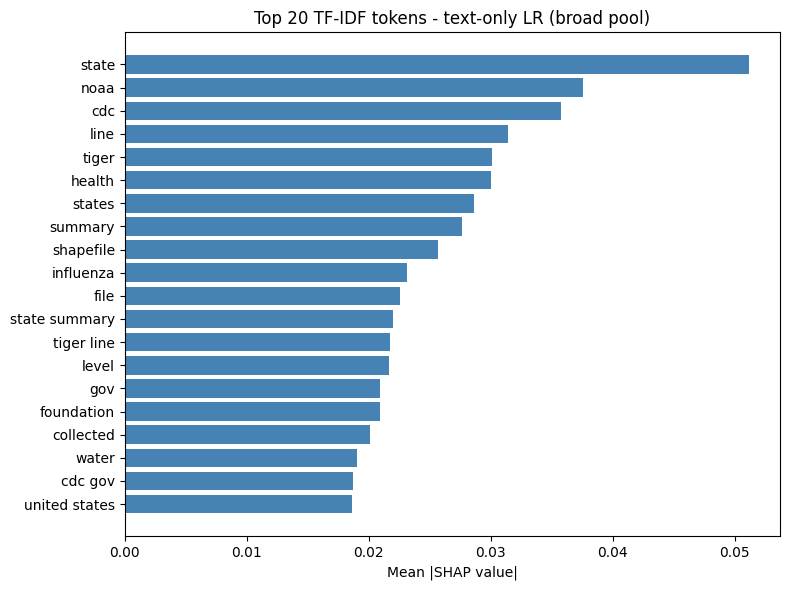

In [ ]:
sv = shap_sv['Text only']
fn = shap_fn['Text only']
mean_sv = np.abs(sv).mean(axis=0)
top  = np.argsort(mean_sv)[-TOP_K:][::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    [clean(fn[i]) for i in top][::-1],
    mean_sv[top][::-1], color='steelblue'
)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top {TOP_K} TF-IDF tokens - text-only LR (broad pool)')
plt.tight_layout(); plt.show()

top features + all metadata (text + meta mdel)

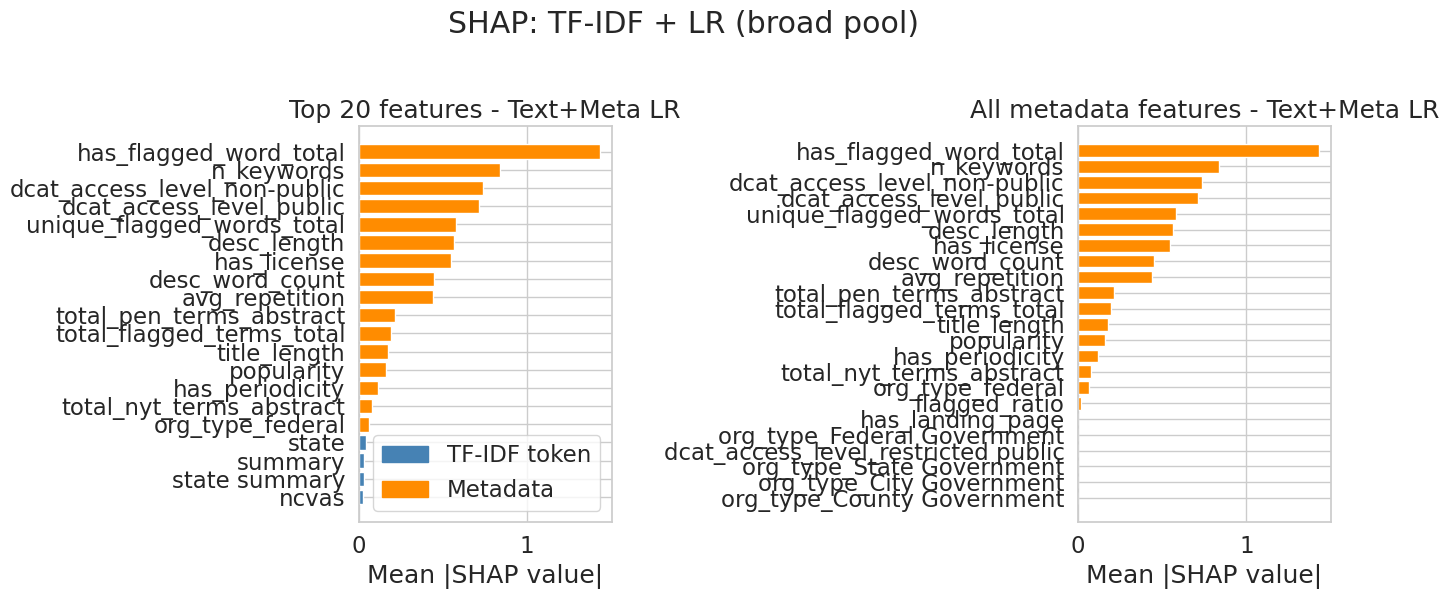

In [ ]:
sv = shap_sv['Text + Meta']
fn = shap_fn['Text + Meta']
mean_sv = np.abs(sv).mean(axis=0)

is_text = np.array([n.startswith('tfidf__') for n in fn])
is_meta = ~is_text

top = np.argsort(mean_sv)[-TOP_K:][::-1]
colors = ['steelblue' if is_text[i] else 'darkorange' for i in top]

meta_names = fn[is_meta]
meta_shap = mean_sv[is_meta]
meta_ord = np.argsort(meta_shap)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(
    [clean(fn[i]) for i in top][::-1],
    mean_sv[top][::-1], color=colors[::-1]
)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Top {TOP_K} features - Text+Meta LR')
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue',  label='TF-IDF token'),
    mpatches.Patch(color='darkorange', label='Metadata'),
], loc='lower right')

axes[1].barh(
    [clean(n) for n in meta_names[meta_ord]][::-1],
    meta_shap[meta_ord][::-1], color='darkorange'
)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('All metadata features - Text+Meta LR')

plt.suptitle('SHAP: TF-IDF + LR (broad pool)', y=1.01)
plt.tight_layout(); plt.show()

group level attribution

In [ ]:
text_c = mean_sv[is_text].sum()
meta_c = mean_sv[is_meta].sum()
total_tm = text_c + meta_c

print(f'tf idf + meta mean absolute attribution')
print(f'tf idf tokens: {text_c:.4f}  ({text_c/total_tm*100:.1f}%)')
print(f'metadata features:{meta_c:.4f}  ({meta_c/total_tm*100:.1f}%)')
print(f'metadata by feature:')
for i in meta_ord:
    print(f'  {clean(meta_names[i]):<40s}  {meta_shap[i]:.5f}')

tf idf + meta mean absolute attribution
tf idf tokens: 2.5983  (26.2%)
metadata features:7.3279  (73.8%)
metadata by feature:
  has_flagged_word_total                    1.42955
  n_keywords                                0.83820
  dcat_access_level_non-public              0.73640
  dcat_access_level_public                  0.71168
  unique_flagged_words_total                0.57999
  desc_length                               0.56581
  has_license                               0.54825
  desc_word_count                           0.44954
  avg_repetition                            0.43819
  total_pen_terms_abstract                  0.21613
  total_flagged_terms_total                 0.19418
  title_length                              0.17622
  popularity                                0.16237
  has_periodicity                           0.11717
  total_nyt_terms_abstract                  0.07885
  org_type_federal                          0.06346
  flagged_ratio                           

### Embeddings + LR

In [ ]:
X_b6_full = np.hstack([X_b4_full, meta_all])

In [ ]:
lr_emb = LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced')
lr_emb.fit(X_b6_full[trainval_idx], y_full[trainval_idx])

explainer = shap.LinearExplainer(lr_emb, bg(X_b6_full[trainval_idx]))
sv = explainer.shap_values(X_b6_full[test_idx])  # (n_test, n_emb + n_meta)

n_emb  = X_b4_full.shape[1]
is_emb = np.array([True]  * n_emb + [False] * meta_all.shape[1])
is_meta  = ~is_emb
meta_names = np.array([clean(n) for n in meta_pre_b6.get_feature_names_out()])
mean_sv = np.abs(sv).mean(axis=0)

emb_c = mean_sv[is_emb].sum()
meta_c_emb = mean_sv[is_meta].sum()
total_emb = emb_c + meta_c_emb

print(f'embeddings + meta mean absolute shap attribution')
print(f' embeddings ({n_emb} dims): {emb_c:.4f}  ({emb_c/total_emb*100:.1f}%)')
print(f' metadata features: {meta_c_emb:.4f}  ({meta_c_emb/total_emb*100:.1f}%)')

embeddings + meta mean absolute shap attribution
 embeddings (1536 dims): 6.5774  (50.3%)
 metadata features: 6.5034  (49.7%)


In [ ]:
meta_shap = mean_sv[is_meta]
meta_ord  = np.argsort(meta_shap)[::-1]

group comarison + meta on embeddings

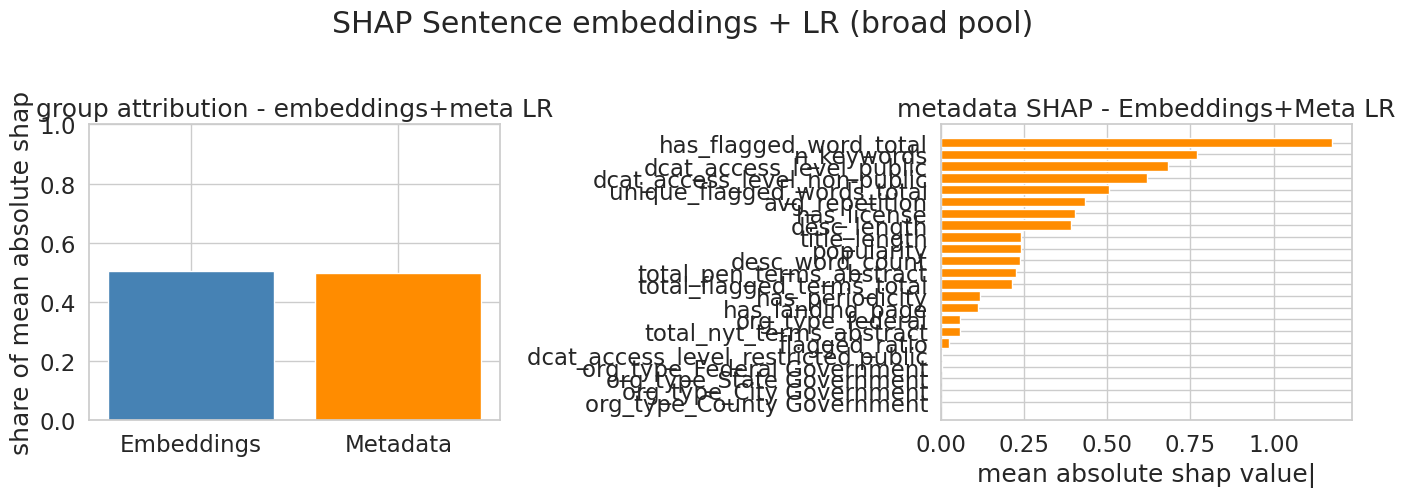

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    ['Embeddings', 'Metadata'],
    [emb_c / total_emb, meta_c_emb / total_emb],
    color=['steelblue', 'darkorange']
)
axes[0].set_ylabel('share of mean absolute shap')
axes[0].set_title('group attribution - embeddings+meta LR')
axes[0].set_ylim(0, 1)

axes[1].barh(meta_names[meta_ord][::-1], meta_shap[meta_ord][::-1], color='darkorange')
axes[1].set_xlabel('mean absolute shap value|')
axes[1].set_title('metadata SHAP - Embeddings+Meta LR')

plt.suptitle('SHAP Sentence embeddings + LR (broad pool)', y=1.01)
plt.tight_layout(); plt.show()

does metadata improve over text only?

In [ ]:
print(f'TF-IDF + meta: metadata = {meta_c/total_tm*100:.1f}%')
print(f'Emb + meta: metadata = {meta_c_emb/total_emb*100:.1f}%')

TF-IDF + meta: metadata = 73.8%
Emb + meta: metadata = 49.7%


##### IN SEABORN

In [ ]:
sns.set_theme(style='whitegrid', font_scale=1.5)

In [ ]:
GROUP_COLS = [
    ('Flagged risk terms', flagged_cols),
    ('Text properties', text_prop_cols),
    ('Engagement',  engagement_cols),
    ('Completeness', completeness_cols),
    ('Org type', org_cat_cols),
    ('Access level', access_cat_cols),
]

GROUP_ORDER = [
    'Text', 'Flagged risk terms', 'Text properties',
    'Engagement', 'Completeness', 'Org type', 'Access level',
]
GROUP_COLORS = {
    'Text':               'steelblue',
    'Flagged risk terms': 'firebrick',
    'Text properties':    'mediumpurple',
    'Engagement':         'cornflowerblue',
    'Completeness':       'darkslateblue',
    'Org type':           'deeppink',
    'Access level':       'hotpink',
}

In [ ]:
def assign_group(feat_name):
    if feat_name.startswith('tfidf__'):
        return 'Text'
    bare = feat_name.split('__', 1)[-1] if '__' in feat_name else feat_name
    for group, cols in GROUP_COLS:
        for col in cols:
            if bare == col or bare.startswith(col + '_'):
                return group
    return 'Other'

aggregate tf idf

In [ ]:
sv   = shap_sv['Text + Meta']
fn   = shap_fn['Text + Meta']
mean_sv = np.abs(sv).mean(axis=0)

totals = {}
for feat, val in zip(fn, mean_sv):
    g = assign_group(feat)
    totals[g] = totals.get(g, 0.0) + val
total_tm = sum(totals.values())
pct_tm = {g: v / total_tm * 100 for g, v in totals.items()}

aggregate embeddings

In [ ]:
mean_sv = np.abs(sv).mean(axis=0)
meta_fn = meta_pre.get_feature_names_out()

totals = {'Text': mean_sv[:n_emb].sum()}
for feat, val in zip(meta_fn, mean_sv[n_emb:]):
    g = assign_group(feat)
    totals[g] = totals.get(g, 0.0) + val
total_emb = sum(totals.values())
pct_b6 = {g: v / total_emb * 100 for g, v in totals.items()}

nice df

In [ ]:
rows = []
for g in GROUP_ORDER:
    if g in pct_tm:
        rows.append({'Group': g, 'Model': 'TF-IDF + LR',     'pct': pct_tm[g]})
    if g in pct_b6:
        rows.append({'Group': g, 'Model': 'Embeddings + LR', 'pct': pct_b6[g]})
df_groups = pd.DataFrame(rows)

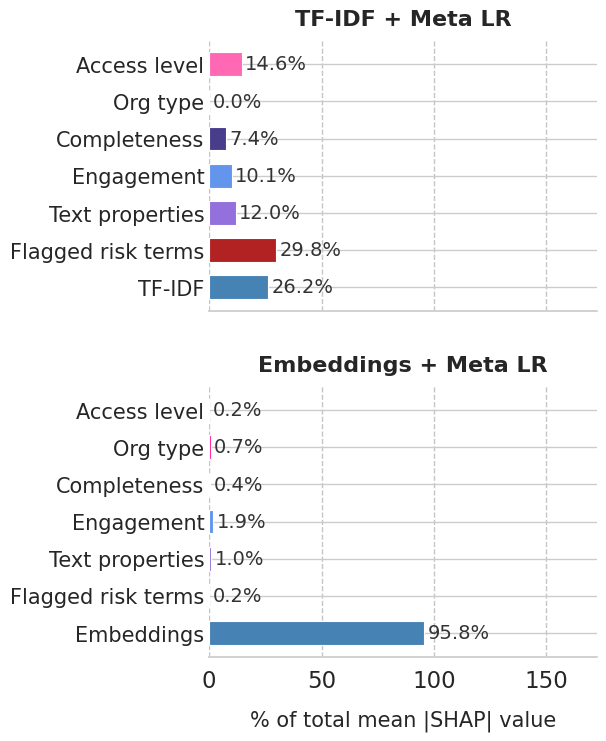

In [ ]:
TEXT_LABELS = {'TF-IDF + LR': 'TF-IDF', 'Embeddings + LR': 'Embeddings'}
MODEL_TITLES = {'TF-IDF + LR': 'TF-IDF + Meta LR', 'Embeddings + LR': 'Embeddings + Meta LR'}
global_max = df_groups['pct'].max()

fig, axes = plt.subplots(2, 1, figsize=(5, 8), sharex=True)
plt.subplots_adjust(hspace=0.28)

for ax, model in zip(axes, ['TF-IDF + LR', 'Embeddings + LR']):
    sub = df_groups[df_groups['Model'] == model].copy()
    sub = sub.set_index('Group').reindex(GROUP_ORDER).dropna().reset_index()

    display_labels = [TEXT_LABELS[model] if g == 'Text' else g for g in sub['Group']]
    colors = [GROUP_COLORS[g] for g in sub['Group']]
    vals = sub['pct'].values
    y_pos = np.arange(len(vals)) * 0.55

    bars = ax.barh(y_pos, vals, color=colors, height=0.35, edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(display_labels, fontsize=15)
    ax.set_title(MODEL_TITLES[model], fontsize=16, fontweight='bold', pad=11)
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, linestyle='--', alpha=0.45, color='grey')
    ax.set_axisbelow(True)
    ax.set_xlim(0, global_max * 1.8)
    ax.set_ylim(-0.35, (len(vals) - 1) * 0.55 + 0.35)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + global_max * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left',
                fontsize=14, color='#333333', fontweight='medium')

    sns.despine(ax=ax, left=True, bottom=False)

axes[1].set_xlabel('% of total mean |SHAP| value', labelpad=12, fontsize=15)
plt.show()

In [ ]:
print(f'\n{'Group':<25}  {'TF-IDF model':>14}  {'Emb model':>10}')
for g in GROUP_ORDER:
    label = 'Text (tokens / emb)' if g == 'Text' else g
    print(f'{label:<23}  {pct_tm.get(g, 0):>13.1f}%  {pct_b6.get(g, 0):>9.1f}%')



Group                        TF-IDF model   Emb model
Text (tokens / emb)               26.2%       95.8%
Flagged risk terms                29.8%        0.2%
Text properties                   12.0%        1.0%
Engagement                        10.1%        1.9%
Completeness                       7.4%        0.4%
Org type                           0.0%        0.7%
Access level                      14.6%        0.2%


MOVE TO FINAL EVAL

In [ ]:
# MOVE TO FINAL EVALUATION
# per-feature AUC: broad pool vs SA pool

# rows = []
# for col in investigate:
#     if col in df.columns:
#         v_b = df[col].fillna(0).values.astype(float)
#         auc_b = _auc(y_full, v_b)
#         auc_b = max(auc_b, 1 - auc_b)
#     else:
#         auc_b = float('nan')
#
#     if col in df_sa.columns:
#         v_s = df_sa[col].fillna(0).values.astype(float)
#         auc_s = _auc(y_sa, v_s)
#         auc_s = max(auc_s, 1 - auc_s)
#     else:
#         auc_s = float('nan')
#
#     drop = auc_b - auc_s
#     rows.append({'feature': col, 'auc_broad': round(auc_b, 4),
#                  'auc_sa': round(auc_s, 4), 'drop': round(drop, 4)})
#
# feat_df = pd.DataFrame(rows).sort_values('auc_broad', ascending=False)
# print(feat_df.to_string(index=False))